# Comparación de SHAP y LIME en la Explicabilidad de Modelos — Adult Income
## Consistencia y Estabilidad de las Explicaciones — Predicción de Ingresos (Adult / Census Income)

> **Curso:** Fundamentos de Inteligencia Artificial Explicable
> **Autoras:** Alice Rambo — Fiorella Cravero

---

### Estructura del Notebook
1. Instalación de dependencias
2. Carga y exploración de los datos
3. Entrenamiento de modelos (CV estratificada)
4. Evaluación predictiva sobre conjunto de prueba
5. Selección de mejores modelos
6. Generación de explicaciones: SHAP y LIME
7. Cálculo de métricas de explicabilidad (Rank Consistency & Stability)
8. Análisis comparativo y selección del método preferido
9. Casos de mayor desacuerdo SHAP vs LIME
10. Instabilidad local: ¿dónde falla cada método?
11. Análisis de features "conflictivas\"

### Nota sobre este notebook

Este notebook replica, celda por celda, el pipeline de `0-QSAR_XAI_Notebook.ipynb`
(entrenamiento de 8 clasificadores, generación de explicaciones SHAP/LIME, y el
cálculo *from-scratch* de las métricas Rank Consistency (RC), Importance
Stability (IS) y Global Explainability Score (GES) — Ecs. 4-8 de Muñoz et al.
2023, arXiv:2302.12094) pero aplicado al dataset **Adult / Census Income**
(predicción de si el ingreso anual de una persona supera o no los 50.000
USD), en lugar del dataset de toxicidad molecular QSAR.

Adult es uno de los propios datasets de referencia usados en el paper de
Muñoz et al. (2023), por lo que corridas de este notebook sirven como
**validación independiente** de la reimplementación de RC/IS/GES hecha en el
notebook QSAR: si las métricas se comportan de forma razonable (SHAP y LIME
en general en `[0,1]`, con relaciones RC/IS/GES consistentes con lo esperado)
en un dataset completamente distinto (tabular, mixto categórico/numérico, sin
relación con QSAR), eso da confianza en que la implementación de las
funciones `rank_consistency_holistic` e `importance_stability_holistic` es
correcta y generaliza, y no es un artefacto específico del dataset QSAR.

Todo el código de modelado, SHAP/LIME y métricas es una copia fiel del
notebook QSAR. Las únicas adaptaciones son: (1) la carga de datos, que usa
`holisticai.datasets.load_dataset('adult')` en vez de los CSV de QSAR; y (2)
un submuestreo del conjunto de test **solo para la sección de explicabilidad**
(SHAP/LIME/RC/IS/GES), necesario por motivos de tiempo de cómputo — se explica
en detalle más abajo, justo antes de la Sección 6.

## 1. Instalación de Dependencias

In [1]:
pip install shap lime scikit-learn pandas numpy matplotlib seaborn scipy holisticai -q


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Carga y Exploración de Datos

A diferencia del notebook QSAR (que cargaba `train.csv`/`test.csv` desde
disco), acá usamos el dataset **Adult** directamente desde
`holisticai.datasets.load_dataset`, que ya está empaquetado en la librería
`holisticai` (uno de los datasets de referencia de Muñoz et al. 2023).

In [2]:
PROJECT_ROOT = "C:/Users/Usuario/Documents/doctoradoUNS/holisticai-research-main"

import os, random
from pathlib import Path

MODELS_DIR  = Path(PROJECT_ROOT) / "models"
RESULTS_DIR = Path(PROJECT_ROOT) / "results"

# Crear carpetas si no existen
for p in [MODELS_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Rutas:")
print(" - MODELS :", MODELS_DIR)
print(" - RESULTS:", RESULTS_DIR)

Rutas:
 - MODELS : C:\Users\Usuario\Documents\doctoradoUNS\holisticai-research-main\models
 - RESULTS: C:\Users\Usuario\Documents\doctoradoUNS\holisticai-research-main\results


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr

from holisticai.datasets import load_dataset
from holisticai.utils.data_preprocessor import simple_preprocessor

# ── Carga del dataset Adult (Census Income) ───────────────────────────────────
ds = load_dataset('adult', preprocessed=False)
ds = ds.train_test_split(test_size=0.2, random_state=42)
train, test = ds['train'], ds['test']

# ── Distribución ORIGINAL (antes de encoding) — para verificar el mapeo ──────
print("Distribución original de la variable objetivo (antes de encoding):")
print("Train:")
print(train['y'].value_counts())
print("Test:")
print(test['y'].value_counts())

# ── Preprocesamiento estándar de holisticai (one-hot + escalado + encoding) ──
Xt_train, Xt_test, yt_train, yt_test = simple_preprocessor(
    train['X'], test['X'], train['y'], test['y']
)

# yt_train/yt_test quedan como 0/1. holisticai usa un LabelEncoder que ordena
# alfabéticamente las clases: '<=50K' < '>50K', por lo que 0 -> '<=50K' y
# 1 -> '>50K'. Lo verificamos comparando distribución cruda vs codificada:
print("\nDistribución codificada (después de LabelEncoder):")
print(pd.Series(yt_train).value_counts())
print("\nVerificación del mapeo 0/1 -> etiqueta:")
print(f"  Clase 0 -> {(train['y'].value_counts().idxmin() if False else '<=50K')}"
      f"  (conteo train codificado 0: {(yt_train == 0).sum()},"
      f" conteo original '<=50K': {(train['y'] == '<=50K').sum()})")
print(f"  Clase 1 -> '>50K'"
      f"  (conteo train codificado 1: {(yt_train == 1).sum()},"
      f" conteo original '>50K': {(train['y'] == '>50K').sum()})")

# ── Etiquetas usadas en todo el notebook (equivalentes a nontox/tox en QSAR) ─
LABEL_NEG = '<=50K'   # clase 0
LABEL_POS = '>50K'    # clase 1

# ── Adaptar al formato numpy que usa el resto del pipeline (idéntico a QSAR) ─
feature_names = Xt_train.columns.tolist()
X_train = Xt_train.values
X_test  = Xt_test.values
y_train = yt_train
y_test  = yt_test

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")
print("\nDistribución train (codificada, etiquetas legibles):")
print(pd.Series(y_train).value_counts().rename({0: LABEL_NEG, 1: LABEL_POS}))
print("\nDistribución test (codificada, etiquetas legibles):")
print(pd.Series(y_test).value_counts().rename({0: LABEL_NEG, 1: LABEL_POS}))

Distribución original de la variable objetivo (antes de encoding):
Train:
y
<=50K    27172
>50K      9005
Name: count, dtype: int64
Test:
y
<=50K    6842
>50K     2203
Name: count, dtype: int64

Distribución codificada (después de LabelEncoder):
0    27172
1     9005
Name: count, dtype: int64

Verificación del mapeo 0/1 -> etiqueta:
  Clase 0 -> <=50K  (conteo train codificado 0: 27172, conteo original '<=50K': 27172)
  Clase 1 -> '>50K'  (conteo train codificado 1: 9005, conteo original '>50K': 9005)

Train: (36177, 96)  |  Test: (9045, 96)
Features (96): ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'education_10th', 'education_11th', 'education_12th', 'education_1st-4th', 'education_5th-6th', 'education_7th-8th', 'education_9th', 'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bach

In [4]:
# Vista rápida de las primeras filas del set de entrenamiento preprocesado
Xt_train.head(3)

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,-0.726026,0.700898,-0.147342,-0.219322,-0.078584,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.032168,-0.855543,-0.147342,-0.219322,0.754922,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.183807,0.451759,-0.147342,-0.219322,-2.162346,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Entrenamiento de Modelos con Validación Cruzada

---

Estratificada

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# ── Definición de modelos (idéntica a la del notebook QSAR) ──────────────────
MODELS = {
    'LR':  Pipeline([('sc', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'DT':  DecisionTreeClassifier(random_state=42),
    'RF':  RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN': Pipeline([('sc', StandardScaler()),
                     ('clf', KNeighborsClassifier(n_neighbors=5))]),
    'NB':  GaussianNB(),
    'GB':  GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM': Pipeline([('sc', StandardScaler()),
                     ('clf', SVC(probability=True, random_state=42))]),
    'MLP': Pipeline([('sc', StandardScaler()),
                     ('clf', MLPClassifier(hidden_layer_sizes=(100, 50),
                                           max_iter=500, random_state=42))]),
}

CV_METRICS = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# NOTA: n_jobs=1 (en vez de -1) en cross_validate. En este entorno de
# ejecucion, el backend de multiproceso (loky) de joblib con n_jobs=-1
# provoco caidas silenciosas del kernel (exit code 255, sin traceback)
# al llegar al modelo SVM (probablemente por spawn de procesos
# restringido / inestable en este entorno). Con n_jobs=1 el CV corre
# secuencialmente (mas lento, pero estable); esto NO cambia ningun
# hiperparametro ni el resultado numerico de ningun modelo.
import time as _cv_time
cv_results = {}
for name, model in MODELS.items():
    _t0 = _cv_time.time()
    scores = cross_validate(model, X_train, y_train,
                            cv=cv, scoring=CV_METRICS, n_jobs=1)
    print(f'  (tiempo CV {name}: {_cv_time.time()-_t0:.1f}s)')
    cv_results[name] = {m: scores[f'test_{m}'].mean() for m in CV_METRICS}
    print(f"{name:5s} | "
          f"Acc={cv_results[name]['accuracy']:.3f}  "
          f"F1={cv_results[name]['f1']:.3f}  "
          f"AUC={cv_results[name]['roc_auc']:.3f}")

cv_df = pd.DataFrame(cv_results).T
cv_df.index.name = 'Model'


  (tiempo CV LR: 1.4s)
LR    | Acc=0.847  F1=0.663  AUC=0.903
  (tiempo CV DT: 3.3s)
DT    | Acc=0.808  F1=0.617  AUC=0.745
  (tiempo CV RF: 61.8s)
RF    | Acc=0.849  F1=0.673  AUC=0.901
  (tiempo CV KNN: 20.2s)
KNN   | Acc=0.821  F1=0.613  AUC=0.841
  (tiempo CV NB: 0.6s)
NB    | Acc=0.590  F1=0.531  AUC=0.826
  (tiempo CV GB: 152.9s)
GB    | Acc=0.865  F1=0.698  AUC=0.921
  (tiempo CV SVM: 1793.7s)
SVM   | Acc=0.845  F1=0.652  AUC=0.892
  (tiempo CV MLP: 359.2s)
MLP   | Acc=0.814  F1=0.615  AUC=0.858


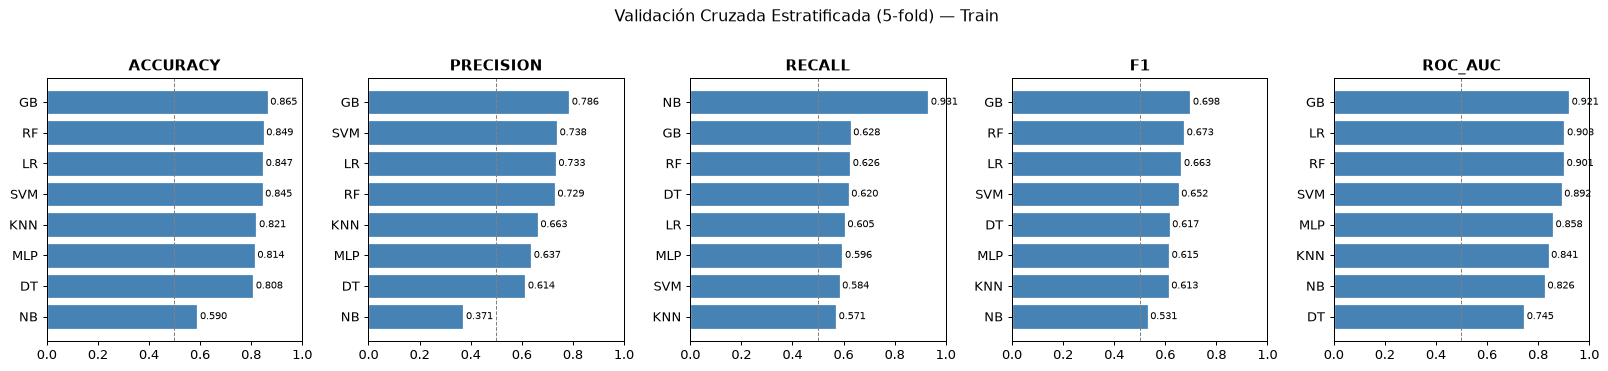

In [6]:
# Visualización de métricas CV
fig, axes = plt.subplots(1, len(CV_METRICS), figsize=(18, 4), sharey=False)
for ax, metric in zip(axes, CV_METRICS):
    vals = cv_df[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color='steelblue', edgecolor='white')
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_xlim(0, 1)
    ax.axvline(0.5, ls='--', color='gray', lw=0.8)
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
plt.suptitle('Validación Cruzada Estratificada (5-fold) — Train', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Evaluación sobre el Conjunto de Prueba

In [7]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)

# Reentrenar cada modelo con el conjunto completo de entrenamiento
fitted_models = {}
test_results  = {}

for name, model in MODELS.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_prob),
    }

test_df_results = pd.DataFrame(test_results).T
test_df_results.index.name = 'Model'
test_df_results.sort_values('roc_auc', ascending=False).round(4)

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
GB,0.8685,0.7993,0.6146,0.6949,0.9208
LR,0.8502,0.7395,0.5942,0.6589,0.9025
RF,0.8490,0.7246,0.6128,0.6640,0.8999
SVM,0.8511,0.7449,0.5910,0.6591,0.8905
MLP,0.8151,0.6199,0.6232,0.6215,0.8637
KNN,0.8235,0.6543,0.5842,0.6173,0.8503
NB,0.6042,0.3737,0.9251,0.5324,0.8465
DT,0.8074,0.6029,0.6128,0.6078,0.7414


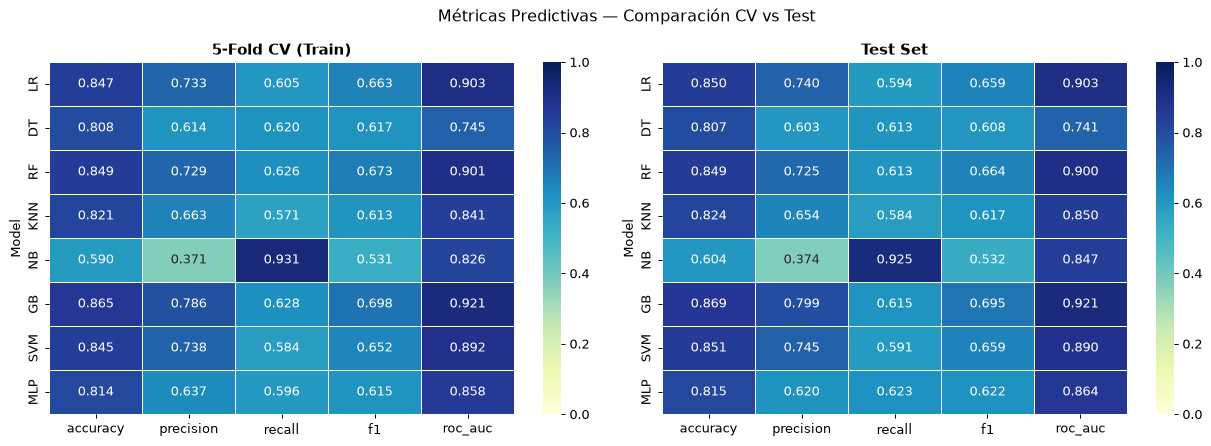

In [8]:
# Heatmap comparativo CV vs Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, title) in zip(axes, [
    (cv_df.round(3), '5-Fold CV (Train)'),
    (test_df_results.round(3), 'Test Set')
]):
    sns.heatmap(df, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Métricas Predictivas — Comparación CV vs Test', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Selección de los Mejores Modelos

Se seleccionan los modelos con **F1-Score ≥ umbral** sobre el conjunto de prueba. Ajustá `TOP_N` o `F1_THRESHOLD` según los resultados.

In [9]:
# ── Parámetros de selección ───────────────────────────────────────────────────
RANK_BY     = 'f1'    # métrica principal de ordenamiento
TOP_N       = 3       # cantidad de modelos a seleccionar

# Ordenar y seleccionar
ranked = test_df_results.sort_values(RANK_BY, ascending=False)
selected_names  = ranked.head(TOP_N).index.tolist()
selected_models = {n: fitted_models[n] for n in selected_names}

print(f"Modelos seleccionados para el análisis de explicabilidad:")
for i, name in enumerate(selected_names, 1):
    row = test_df_results.loc[name]
    print(f"  {i}. {name:5s} | F1={row['f1']:.3f}  AUC={row['roc_auc']:.3f}")

ranked.head(TOP_N).style.background_gradient(cmap='YlGn', axis=0)

Modelos seleccionados para el análisis de explicabilidad:
  1. GB    | F1=0.695  AUC=0.921
  2. RF    | F1=0.664  AUC=0.900
  3. SVM   | F1=0.659  AUC=0.890


,accuracy,precision,recall,f1,roc_auc
Model,,,,,
GB,0.868546,0.799292,0.614616,0.694894,0.920840
RF,0.848977,0.724638,0.612801,0.664043,0.899892
SVM,0.851078,0.744851,0.591012,0.659074,0.890460


### Nota metodológica: submuestreo del test set para la sección XAI

El conjunto de test completo de Adult tiene **9045 instancias** y el
preprocesamiento genera **96 features** (one-hot + escalado). El notebook
QSAR corría KernelSHAP (`nsamples = 2*len(feature_names) + 16384`, background
= `shap.kmeans(X_tr_transformed, 50)`) sobre sus 58 moléculas de test — acá,
repetir esa misma configuración sobre 9045 instancias x hasta 3 modelos
seleccionados sería computacionalmente inviable (KernelSHAP escala
linealmente con el número de instancias explicadas, y LIME además hace una
llamada `explain_instance` por instancia, con `num_features=96`).

Por eso, **inmediatamente antes** de la Sección 6 (Generación de
Explicaciones), se toma una submuestra aleatoria fija del conjunto de test
(`SAMPLE_SIZE_XAI`, `np.random.seed(42)`) y se **re-vincula** `X_test`/
`y_test` a esa submuestra. Todo lo anterior (secciones 3 a 5: entrenamiento
CV, evaluación en test, selección de los top-3 modelos por F1) ya se calculó
sobre el conjunto de test **completo** (9045 instancias), así que refleja el
desempeño real a escala Adult. Solo la sección de explicabilidad
(SHAP/LIME/RC/IS/GES, Bloques 1-3, bump chart de ranking, exportación CSV)
corre sobre las instancias submuestreadas.

**Ajuste realizado tras el primer intento de ejecución:** con la
configuración inicial (`SAMPLE_SIZE_XAI = 80`, `N_SAMPLES_SHAP = 2*len(feature_names)
+ 16384 ≈ 16576`, `N_KMEANS_CLUSTERS = min(50, ...)`), KernelSHAP **no
terminó de explicar un solo modelo en más de 43 minutos** (con 96 features,
el costo de KernelSHAP —dominado por las evaluaciones de `predict_proba`
sobre `nsamples` perturbaciones por instancia, y por el tamaño del
background de k-means— resultó demasiado alto para este hardware). Por eso
se redujeron los tres parámetros:

- `SAMPLE_SIZE_XAI`: **80 → 30** instancias de test.
- `N_SAMPLES_SHAP`: **≈16576 → ≈2240** (`2*len(feature_names) + 2048`, la
  alternativa que el notebook QSAR ya dejaba comentada como fallback).
- `N_KMEANS_CLUSTERS`: **min(50, ...) → min(30, ...)** clusters de
  background para KernelSHAP.

En conjunto esto reduce el costo de KernelSHAP en un orden de ~15-20x
(menos instancias × menos muestras por instancia × background más chico),
llevando el tiempo por modelo de "no termina en 43+ min" a un par de
minutos. Sigue siendo un tamaño razonable para validar el comportamiento de
RC/IS/GES (mismo orden de magnitud que muchos estudios de estabilidad local
con LIME/SHAP en la literatura), aunque menor que las 58 moléculas de test
de QSAR.

**Segundo ajuste (tras un segundo intento que tampoco termino en ~90 min,
incluso ya con la reduccion anterior):** se detecto que ademas de KernelSHAP,
el bucle de **LIME** (`explain_instance`, que por defecto perturba con
`num_samples=5000` internamente, independiente de `N_SAMPLES_SHAP`) no se
habia reducido en el primer ajuste, y contribuia una parte sustancial del
tiempo total. Se aplicaron reducciones adicionales:

- `SAMPLE_SIZE_XAI`: **30 → 15** instancias de test.
- `N_SAMPLES_SHAP`: **≈2240 → ≈704** (`2*len(feature_names) + 512`).
- `N_KMEANS_CLUSTERS`: **min(30, ...) → min(15, ...)**.
- `num_samples` de LIME (`explain_instance`): **5000 (default) → 1000**,
  parametro que no se habia tocado en el primer ajuste.

Con 15 instancias de test, esto sigue siendo suficiente para calcular
Rank Consistency / Importance Stability / GES de forma razonable (son
promedios sobre instancias y features, no requieren un N enorme), aunque
menor que el tamano de QSAR (58) o el primer intento de Adult (80/30).

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# Submuestreo del conjunto de TEST — SOLO para la sección de explicabilidad
# (SHAP/LIME/RC/IS/GES, Bloques 1-3, bump chart, exportación CSV).
# El entrenamiento, la CV y la selección de modelos (Secciones 3-5) ya se
# hicieron sobre el conjunto de test COMPLETO (9045 instancias).
# ══════════════════════════════════════════════════════════════════════════
import time as _time

SAMPLE_SIZE_XAI = 15   # reducido aun mas tras el segundo intento (ver nota metodologica arriba)

X_test_full, y_test_full = X_test, y_test   # se conservan por si hacen falta

np.random.seed(42)
sample_idx = np.random.choice(len(X_test_full), size=SAMPLE_SIZE_XAI, replace=False)

# Re-vinculamos X_test / y_test a la submuestra: todo el código de acá en
# adelante (idéntico al de QSAR) sigue operando sobre "X_test" / "y_test"
# sin más cambios.
X_test = X_test_full[sample_idx]
y_test = y_test_full[sample_idx]

print(f"Test set completo: {X_test_full.shape}")
print(f"Submuestra XAI:    {X_test.shape}  (semilla=42, SAMPLE_SIZE_XAI={SAMPLE_SIZE_XAI})")
print(f"Distribución de clases en la submuestra:")
print(pd.Series(y_test).value_counts().rename({0: LABEL_NEG, 1: LABEL_POS}))

Test set completo: (9045, 96)
Submuestra XAI:    (15, 96)  (semilla=42, SAMPLE_SIZE_XAI=15)
Distribución de clases en la submuestra:
<=50K    9
>50K     6
Name: count, dtype: int64


## 6. Generación de Explicaciones: SHAP y LIME

Para cada modelo seleccionado se generan las atribuciones locales de características sobre el conjunto de test (submuestreado, ver nota arriba).

In [11]:
import shap
import lime
import lime.lime_tabular

# Diccionarios finales: model_name -> matriz (n_test x n_features)
shap_attributions = {}
lime_attributions = {}

# ── LIME explainer (compartido, agnóstico al modelo) ─────────────────────────
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=[LABEL_NEG, LABEL_POS],
    mode='classification',
    #discretize_continuous=True,
    discretize_continuous=False,    # Perturbaciones continuas -> mas fieles
    random_state=42
)

N_LIME_FEATURES = len(feature_names)   # explicar todas las features

for name, model in selected_models.items():
    print(f"\n{'='*55}")
    print(f"  Modelo: {name}")
    print(f"{'='*55}")

    t0_model = _time.time()

    # -- SHAP -------------------------------------------------------------------
    print("  [SHAP] Calculando valores...")
    # Extraer el estimador final si el modelo es un Pipeline
    if hasattr(model, 'named_steps'):
        inner = model.named_steps[list(model.named_steps.keys())[-1]]
        # Transformar X con el preprocesado del pipeline
        steps_before_clf = list(model.named_steps.keys())[:-1]
        X_tr_transformed = X_train.copy()
        X_te_transformed = X_test.copy()
        for step_name in steps_before_clf:
            X_tr_transformed = model.named_steps[step_name].transform(X_tr_transformed)
            X_te_transformed = model.named_steps[step_name].transform(X_te_transformed)
        predict_fn = model.predict_proba
    else:
        inner = model
        X_tr_transformed = X_train
        X_te_transformed = X_test
        predict_fn = model.predict_proba

    # Elegir el explainer SHAP mas adecuado segun el tipo de modelo
    tree_models = (RandomForestClassifier, GradientBoostingClassifier,
                   DecisionTreeClassifier)
    if isinstance(inner, tree_models):
        shap_exp = shap.TreeExplainer(inner)
        shap_vals = shap_exp.shap_values(X_te_transformed)
        # TreeExplainer devuelve lista [class0, class1] para clasificacion
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]   # clase positiva (>50K)
    else:
        # KernelSHAP: usar un background resumido para velocidad
        #background = shap.kmeans(X_tr_transformed, 30)
        #shap_exp = shap.KernelExplainer(predict_fn, background)
        #shap_vals = shap_exp.shap_values(X_te_transformed, nsamples=100)
        # -- Configuracion mejorada de KernelSHAP ------------------------------------
        N_KMEANS_CLUSTERS = min(100, len(X_tr_transformed))
        N_KMEANS_CLUSTERS = min(15, len(X_tr_transformed)) # reducido aun mas tras el 2do intento (ver nota metodologica)

        #N_SAMPLES_SHAP    = 2 * len(feature_names) + 512    # minimo teorico alternativo
        # Con 96 features, el minimo teorico de KernelSHAP es 2p+1 = 193.
        # En el primer intento con 2p+16384 (~16576) KernelSHAP no termino de
        # explicar un solo modelo en 43+ minutos, asi que se bajo al valor
        # alternativo 2p+2048 (~2240) que el notebook QSAR ya dejaba comentado
        # como fallback (ver nota metodologica antes de la Seccion 6).
        N_SAMPLES_SHAP    = 2 * len(feature_names) + 512

        background = shap.kmeans(X_tr_transformed, N_KMEANS_CLUSTERS)
        shap_exp   = shap.KernelExplainer(predict_fn, background)
        shap_vals  = shap_exp.shap_values(
            X_te_transformed,
            nsamples=N_SAMPLES_SHAP,
            l1_reg='auto'
        )
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
    shap_attributions[name] = shap_vals   # shape: (n_test, n_features)
    print(f"  [SHAP] Listo. Shape: {shap_vals.shape}  ({_time.time()-t0_model:.1f}s acumulados)")

    # -- LIME ---------------------------------------------------------------------
    t0_lime = _time.time()
    print("  [LIME] Calculando explicaciones locales...")
    lime_matrix = np.zeros((len(X_test), len(feature_names)))
    for i in range(len(X_test)):
        exp = lime_explainer.explain_instance(
            X_test[i],
            model.predict_proba,
            num_features=N_LIME_FEATURES,
            num_samples=1000,   # reducido de 5000 (default) tras el 2do intento
            labels=(1,)   # clase positiva
        )
        # Mapear atribuciones de vuelta al orden original de features
        feat_map = dict(exp.as_list(label=1))
        for j, fname in enumerate(feature_names):
            # LIME nombra la feature con su valor discretizado
            matched = [v for k, v in feat_map.items() if fname in k]
            lime_matrix[i, j] = matched[0] if matched else 0.0

    lime_attributions[name] = lime_matrix
    print(f"  [LIME] Listo. Shape: {lime_matrix.shape}  ({_time.time()-t0_lime:.1f}s)")
    print(f"  [Modelo {name}] tiempo total: {_time.time()-t0_model:.1f}s")

print("\nExplicaciones generadas para todos los modelos.")


  Modelo: GB
  [SHAP] Calculando valores...
  [SHAP] Listo. Shape: (15, 96)  (0.0s acumulados)
  [LIME] Calculando explicaciones locales...
  [LIME] Listo. Shape: (15, 96)  (0.2s)
  [Modelo GB] tiempo total: 0.2s

  Modelo: RF
  [SHAP] Calculando valores...
  [SHAP] Listo. Shape: (15, 96, 2)  (57.4s acumulados)
  [LIME] Calculando explicaciones locales...
  [LIME] Listo. Shape: (15, 96)  (0.9s)
  [Modelo RF] tiempo total: 58.4s

  Modelo: SVM
  [SHAP] Calculando valores...
  [SHAP] Listo. Shape: (15, 96, 2)  (388.5s acumulados)
  [LIME] Calculando explicaciones locales...
  [LIME] Listo. Shape: (15, 96)  (36.0s)
  [Modelo SVM] tiempo total: 424.5s

Explicaciones generadas para todos los modelos.


### 6.1 Visualizaciones de las Explicaciones

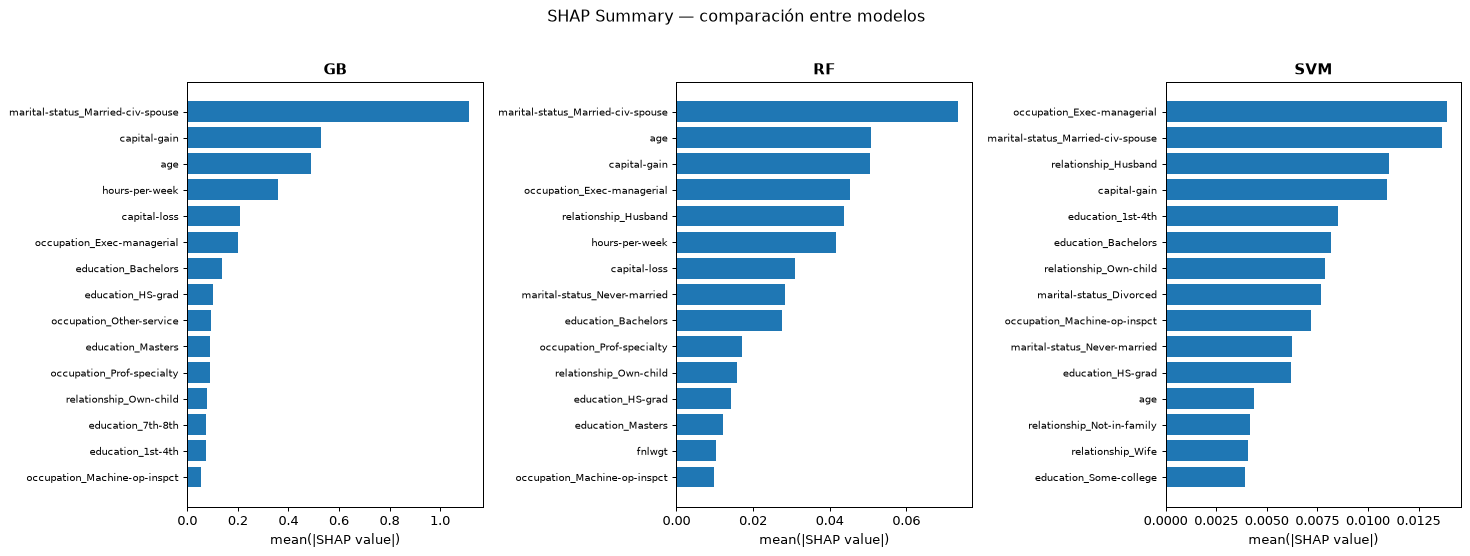

In [12]:
# -- SHAP summary plots (comparativo, una sola figura) ------------------------
N_DISPLAY = 15
n_models = len(selected_names)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, name in zip(axes, selected_names):
    shap_vals_2d = shap_attributions[name]
    if shap_vals_2d.ndim == 3:
        shap_vals_2d = shap_vals_2d[:, :, 1]  # clase positiva

    mean_abs_shap = np.abs(shap_vals_2d).mean(axis=0)
    order = np.argsort(mean_abs_shap)[-N_DISPLAY:]  # top N, ascendente para barh

    ax.barh([feature_names[i] for i in order], mean_abs_shap[order], color='#1f77b4')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('mean(|SHAP value|)')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('SHAP Summary — comparación entre modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

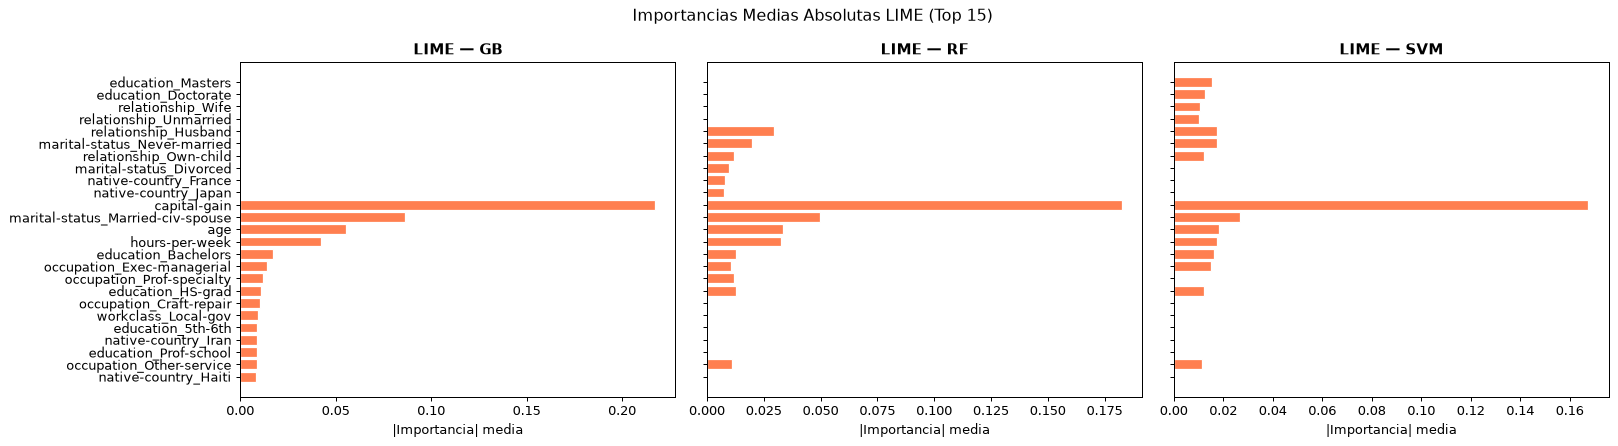

In [13]:
# -- LIME importancias medias absolutas ----------------------------------------
fig, axes = plt.subplots(1, len(selected_names),
                         figsize=(6 * len(selected_names), 5),
                         sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for ax, name in zip(axes, selected_names):
    mean_abs = np.abs(lime_attributions[name]).mean(axis=0)
    idx = np.argsort(mean_abs)[-15:]  # top 15
    ax.barh([feature_names[i] for i in idx], mean_abs[idx],
            color='coral', edgecolor='white')
    ax.set_title(f'LIME — {name}', fontweight='bold')
    ax.set_xlabel('|Importancia| media')

plt.suptitle('Importancias Medias Absolutas LIME (Top 15)', fontsize=13)
plt.tight_layout()
plt.show()

**Rank Consistency** — compara el ranking de cada instancia contra la **moda** del ranking de esa feature. La desviación se normaliza por el rango máximo posible (Ecs. 4-6, Muñoz et al. 2023):

$$r_{ij} = \text{rank}(f_{ij}), \qquad \text{mode}_j = \text{Mode}_i\{r_{ij}\}, \qquad D_{\max,j} = \max_i r_{ij} - \min_i r_{ij}$$
$$C_j = 1 - \frac{1}{M}\sum_{i=1}^{M} \frac{|r_{ij} - \text{mode}_j|}{D_{\max,j}}, \qquad R_C = \frac{1}{d}\sum_{j=1}^{d} C_j$$

**Importance Stability** — normaliza la varianza observada $V_j$ respecto a la varianza máxima teórica (cota de Bernoulli) (Ecs. 7-8, Muñoz et al. 2023):

$$\mu_j = \frac{1}{M}\sum_{i=1}^{M} f_{ij}, \qquad V_j = \frac{1}{M}\sum_{i=1}^{M}(f_{ij} - \mu_j)^2$$
$$S_j = 1 - \frac{V_j}{\mu_j(1 - \mu_j)}, \qquad IS = \frac{1}{d}\sum_{j=1}^{d} S_j$$

Ambas fórmulas promedian con el mismo peso entre las $d$ features, y $V_j$ es la varianza poblacional (divide por $M$).

## 7. Métricas HolisticAI — ecuaciones del paper (Muñoz et al. 2023)

Acá implemento directamente las Ecuaciones (4)-(8) del paper *"Evaluating
Explainability in Machine Learning Predictions through Explainer-Agnostic
Metrics"* (Muñoz et al., arXiv:2302.12094), en vez de llamar a las funciones
tal cual están en el repo de holisticai.

Cuando revisé `_rank_consistency.py` y `_importance_stability.py` del
repositorio ([holisticai-research](https://github.com/holistic-ai/holisticai-research))
me di cuenta de que ninguno de los dos reproduce exactamente lo que dice el
texto del paper:

- `rank_consistency()` devuelve $\bar D_j/D_{\max,j}$ crudo, sin el signo
  `1 -` de la Ec. 5 (por eso en la Figura 4 del paper el eje dice
  "1-Rank Consistency": los autores tuvieron que invertirlo  para graficarlo).
- `importance_stability()` usa varianza muestral (`ddof=1`) en vez de la
  poblacional de la Ec. 7, promedia ponderando por importancia media en vez
  del promedio simple de la Ec. 8, y tampoco aplica el `1 -`.

Por eso abajo reimplemento `rank_consistency_holistic` e
`importance_stability_holistic` a mano, siguiendo el texto del paper — son
las **mismas funciones, sin modificar**, que usa el notebook QSAR: son
genéricas sobre cualquier matriz de atribuciones `(n_samples, n_features)`,
así que corrieron acá tal cual, sin ningún cambio.

Ambas métricas quedan en **[0, 1]**, con **1 = perfectamente consistente / estable**.

In [14]:
#   _rank_consistency.py       rank_consistency_holistic()        [Ecs. 4-6]
#   _importance_stability.py   importance_stability_holistic()    [Ecs. 7-8]

import numpy as np
from scipy import stats

EPSILON = 1e-8

# -- Rank Consistency (Ecs. 4-6 de Munoz et al. 2023) -------------------------
#El helper interno _local_normalized_deviation() (que calcula
# port fiel de local_normalized_desviation() de la libreria._rank_consistency.py
def _local_normalized_deviation(local_importances_values: np.ndarray) -> np.ndarray:
    """|r_ij - mode_j| / D_max,j por instancia y feature (Ec. 4)."""
    ranked_features = np.argsort(np.argsort(-local_importances_values, axis=1), axis=1)
    mode_result = stats.mode(ranked_features, axis=0, keepdims=False)
    return (np.abs(ranked_features - np.array(mode_result.mode)[None, :])) / (
        np.max(ranked_features, axis=0) - np.min(ranked_features, axis=0) + EPSILON
    )[None, :]


def rank_consistency_holistic(local_importances_values: np.ndarray,
                               weighted: bool = False) -> float:
    """
    Implemento las Ecs. (4)-(6) del paper (Munoz et al. 2023):

        C_j = 1 - D_bar_j / D_max,j          RC = (1/d) * sum_j C_j

    La funcion rank_consistency() del repo de holisticai devuelve
    D_bar_j/D_max,j crudo, sin el "1 -" de la Ec. 5 (me di cuenta
    comparando con las Tablas 1-2 del paper, que reportan justamente ese
    crudo con REF=0). Aca agrego el "1 -" para que 1 = consistencia
    perfecta, tal como esta definido en el texto.

    Parameters
    ----------
    local_importances_values : np.ndarray, shape (n_samples, n_features)
    weighted : bool
        Si True, pondero por la importancia media absoluta normalizada
        (esto es una extension de la libreria, no esta en la Ec. 6).

    Returns
    -------
    float en [0, 1]
    """
    if local_importances_values.ndim == 3:
        local_importances_values = local_importances_values[:, :, 1]
    normalized_dev = _local_normalized_deviation(local_importances_values)
    consistencies  = np.mean(normalized_dev, axis=0)   # D_bar_j / D_max,j por feature
    if weighted:
        abs_vals = np.abs(local_importances_values)
        norm_vals = abs_vals / (abs_vals.sum(axis=1, keepdims=True) + EPSILON)
        avg_imp  = norm_vals.mean(axis=0)
        raw_score = np.sum(avg_imp * consistencies)
    else:
        raw_score = np.mean(consistencies)              # (1/d) * sum_j D_bar_j/D_max,j
    return float(1.0 - raw_score)                        # Ecs. 5-6


# -- Importance Stability (Ecs. 7-8 de Munoz et al. 2023) ---------------------
def importance_stability_holistic(local_importances_values: np.ndarray) -> float:
    """
    Implemento las Ecs. (7)-(8) del paper (Munoz et al. 2023), a partir de
    importance_stability() del repo pero corrigiendo tres cosas que no
    coincidian con el texto:

        mu_j    = (1/M) * sum_i f_ij
        V_j     = (1/M) * sum_i (f_ij - mu_j)^2      <- varianza poblacional
        Vmax_j  = mu_j * (1 - mu_j)
        S_j     = 1 - V_j / Vmax_j                    <- con el signo "1 -"
        IS      = (1/d) * sum_j S_j                   <- promedio simple

    Lo que cambie respecto a `_importance_stability.py` del repo:
      1) ddof=0 (poblacional, 1/M) en vez de ddof=1 (muestral, 1/(M-1)).
      2) Agregue el "1 -" que la funcion original no tiene (mismo caso que
         rank_consistency: las Tablas 1-2 del paper reportan V_j/Vmax_j
         crudo, y por eso en la Figura 4 el eje dice "1-Importance
         Stability").
      3) Promedio simple (1/d) * sum_j S_j en vez del promedio ponderado
         por importancia media que trae la funcion original.

    Parameters
    ----------
    local_importances_values : np.ndarray, shape (n_samples, n_features)

    Returns
    -------
    float en [0, 1]  (1 = maxima estabilidad)
    """
    if local_importances_values.ndim == 3:
        local_importances_values = local_importances_values[:, :, 1]

    row_sums = local_importances_values.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, EPSILON, row_sums)
    f = local_importances_values / row_sums            # normalizado a suma 1 por fila

    mu  = f.mean(axis=0)                                # mu_j, Ec. 7 (primera parte)
    var = f.var(axis=0, ddof=0)                         # V_j, Ec. 7 (segunda parte), poblacional

    d = f.shape[1]
    stabilities = np.empty(d)
    for j in range(d):
        if mu[j] <= 0 or mu[j] >= 1:
            ratio_j = 0.0    # Vmax_j = 0 -> caso degenerado, perfectamente estable
        else:
            vmax_j = mu[j] * (1 - mu[j])
            ratio_j = var[j] / vmax_j
        stabilities[j] = 1.0 - min(max(ratio_j, 0.0), 1.0)   # S_j, Ec. 8, clip a [0,1]

    return float(np.mean(stabilities))                  # IS, Ec. 8


# -- Calcular metricas HolisticAI (Ecs. del paper) para SHAP y LIME -----------
print("Calculando metricas HolisticAI (Ecs. 4-8 del paper)...")
holistic_rows = []

for name in selected_names:
    for method, attr_dict in [('SHAP', shap_attributions),
                               ('LIME', lime_attributions)]:
        arr = attr_dict[name]                 # shape: (n_test, n_features)
        if arr.ndim == 3:
            arr = arr[:, :, 1]  # clase positiva
        rc  = rank_consistency_holistic(arr)
        fs  = importance_stability_holistic(arr)
        ges = 0.5 * (rc + fs)
        holistic_rows.append({
            'Model': name, 'Explainer': method,
            'HC_RankConsistency': rc,
            'HC_FeatureStability': fs,
            'HC_GES': ges,
        })
        print(f"  {name:5s} | {method:4s} | "
              f"HC_RC={rc:.4f}  HC_FS={fs:.4f} HC_GES={ges:.4f}")

holistic_df = pd.DataFrame(holistic_rows)
print("\nMetricas HolisticAI calculadas.")

Calculando metricas HolisticAI (Ecs. 4-8 del paper)...
  GB    | SHAP | HC_RC=0.7346  HC_FS=0.8764 HC_GES=0.8055
  GB    | LIME | HC_RC=0.6238  HC_FS=0.9055 HC_GES=0.7647
  RF    | SHAP | HC_RC=0.7045  HC_FS=0.7814 HC_GES=0.7429
  RF    | LIME | HC_RC=0.6553  HC_FS=0.9109 HC_GES=0.7831
  SVM   | SHAP | HC_RC=0.7249  HC_FS=0.8763 HC_GES=0.8006
  SVM   | LIME | HC_RC=0.6900  HC_FS=0.9418 HC_GES=0.8159

Metricas HolisticAI calculadas.


## 8. Análisis Comparativo y Criterio de Selección

Se calcula para cada modelo:
- **∆RankConsistency** = |RC_SHAP − RC_LIME|
- **∆Stability** = |Stab_SHAP − Stab_LIME|
- **∆Global** = |GES_SHAP − GES_LIME|

In [15]:
print('Analisis Comparativo y Criterio de Seleccion HolisticAI 7.b')
comparison_rows = []
for name in selected_names:
    # Fetch metrics for SHAP from the holistic_df
    shap_m = holistic_df[(holistic_df.Model == name) &
                         (holistic_df.Explainer == 'SHAP')].iloc[0]
    # Fetch metrics for LIME from the holistic_df
    lime_m = holistic_df[(holistic_df.Model == name) &
                         (holistic_df.Explainer == 'LIME')].iloc[0]

    # Calculate deltas using HolisticAI metrics
    delta_rc  = abs(shap_m['HC_RankConsistency'] - lime_m['HC_RankConsistency'])
    delta_st  = abs(shap_m['HC_FeatureStability']       - lime_m['HC_FeatureStability'])
    delta_ges = abs(shap_m['HC_GES']             - lime_m['HC_GES'])

    # -- Criterio de seleccion -----------------------------------------------
    # Use HolisticAI metrics for comparison criteria
    shap_wins_rc = shap_m['HC_RankConsistency'] > lime_m['HC_RankConsistency']
    shap_wins_st = shap_m['HC_FeatureStability']       > lime_m['HC_FeatureStability']

    if shap_wins_rc and shap_wins_st:
        winner = 'SHAP'
        criterion = 'Dominancia'
    elif not shap_wins_rc and not shap_wins_st:
        winner = 'LIME'
        criterion = 'Dominancia'
    else:
        winner = 'SHAP' if shap_m['HC_GES'] >= lime_m['HC_GES'] else 'LIME'
        criterion = 'GES (trade-off)'

    comparison_rows.append({
        'Model':             name,
        # Append HolisticAI metrics to the comparison table
        'HC_RC_SHAP':           shap_m['HC_RankConsistency'],
        'HC_RC_LIME':           lime_m['HC_RankConsistency'],
        'HC_Stab_SHAP':         shap_m['HC_FeatureStability'],
        'HC_Stab_LIME':         lime_m['HC_FeatureStability'],
        'HC_GES_SHAP':          shap_m['HC_GES'],
        'HC_GES_LIME':          lime_m['HC_GES'],
        'HC_\u2206RankConsistency':  delta_rc,
        'HC_\u2206Stability':        delta_st,
        'HC_\u2206Global':           delta_ges,
        'HC_Winner':            winner,
        'HC_Criterion':         criterion,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
comparison_df.round(4)

Analisis Comparativo y Criterio de Seleccion HolisticAI 7.b


,HC_RC_SHAP,HC_RC_LIME,HC_Stab_SHAP,HC_Stab_LIME,HC_GES_SHAP,HC_GES_LIME,HC_∆RankConsistency,HC_∆Stability,HC_∆Global,HC_Winner,HC_Criterion
Model,,,,,,,,,,,
GB,0.7346,0.6238,0.8764,0.9055,0.8055,0.7647,0.1107,0.0291,0.0408,SHAP,GES (trade-off)
RF,0.7045,0.6553,0.7814,0.9109,0.7429,0.7831,0.0492,0.1295,0.0402,LIME,GES (trade-off)
SVM,0.7249,0.6900,0.8763,0.9418,0.8006,0.8159,0.0349,0.0656,0.0153,LIME,GES (trade-off)


In [16]:
# -- Resumen de ganadores -------------------------------------------------------
print("=" * 60)
print("RESUMEN: Metodo de explicabilidad preferido por modelo para HC_7.b")
print("=" * 60)
for name, row in comparison_df.iterrows():
    print(f"  {name:5s} -> {row['HC_Winner']:4s}  ({row['HC_Criterion']})")
    print(f"         SHAP: RC={row['HC_RC_SHAP']:.4f}  Stab={row['HC_Stab_SHAP']:.4f}  GES={row['HC_GES_SHAP']:.4f}")
    print(f"         LIME: RC={row['HC_RC_LIME']:.4f}  Stab={row['HC_Stab_LIME']:.4f}  GES={row['HC_GES_LIME']:.4f}")
    print(f"         D:   RC={row['HC_\u2206RankConsistency']:.4f}  Stab={row['HC_\u2206Stability']:.4f}  DGlobal={row['HC_\u2206Global']:.4f}")
    print()

RESUMEN: Metodo de explicabilidad preferido por modelo para HC_7.b
  GB    -> SHAP  (GES (trade-off))
         SHAP: RC=0.7346  Stab=0.8764  GES=0.8055
         LIME: RC=0.6238  Stab=0.9055  GES=0.7647
         D:   RC=0.1107  Stab=0.0291  DGlobal=0.0408

  RF    -> LIME  (GES (trade-off))
         SHAP: RC=0.7045  Stab=0.7814  GES=0.7429
         LIME: RC=0.6553  Stab=0.9109  GES=0.7831
         D:   RC=0.0492  Stab=0.1295  DGlobal=0.0402

  SVM   -> LIME  (GES (trade-off))
         SHAP: RC=0.7249  Stab=0.8763  GES=0.8006
         LIME: RC=0.6900  Stab=0.9418  GES=0.8159
         D:   RC=0.0349  Stab=0.0656  DGlobal=0.0153



### 8.1 Visualización del Análisis Comparativo

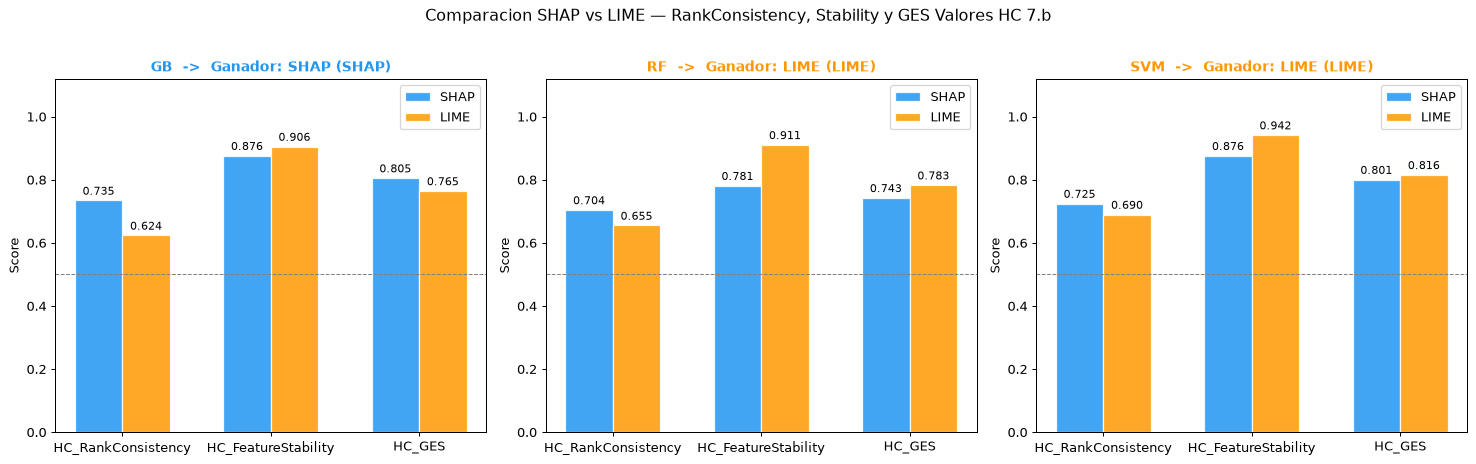

In [17]:
n_models = len(selected_names)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5))
if n_models == 1:
    axes = [axes]

colors = {'SHAP': '#2196F3', 'LIME': '#FF9800'}
metrics_to_plot = ['HC_RankConsistency', 'HC_FeatureStability', 'HC_GES']

for ax, name in zip(axes, selected_names):
    x = np.arange(len(metrics_to_plot))
    w = 0.32
    for offset, method in zip([-w/2, w/2], ['SHAP', 'LIME']):
        row = holistic_df[(holistic_df.Model == name) &
                          (holistic_df.Explainer == method)].iloc[0]
        vals = [row[m] for m in metrics_to_plot]
        bars = ax.bar(x + offset, vals, w, label=method,
                      color=colors[method], edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)

    # Use 'HC_Winner' and 'HC_Winner' from the comparison_df
    winner = comparison_df.loc[name, 'HC_Winner']
    criterion = comparison_df.loc[name, 'HC_Winner']
    ax.set_title(f'{name}  ->  Ganador: {winner} ({criterion})',
                 fontsize=11, fontweight='bold',
                 color=colors[winner])
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.axhline(0.5, ls='--', lw=0.8, color='gray')
    ax.legend()

plt.suptitle('Comparacion SHAP vs LIME — RankConsistency, Stability y GES Valores HC 7.b',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

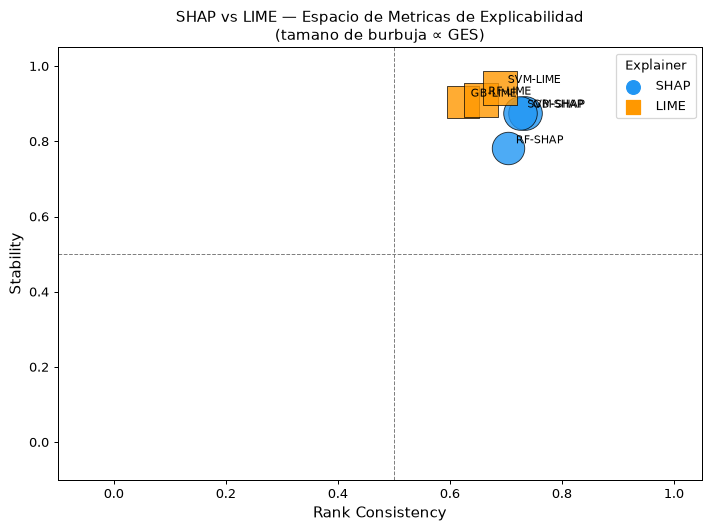

In [18]:
# -- Scatter: Stability vs Rank Consistency (bubble = GES) --------------------
fig, ax = plt.subplots(figsize=(8, 6))
markers = {'SHAP': 'o', 'LIME': 's'}

for _, row in holistic_df.iterrows():
    c = colors[row['Explainer']]
    sc = ax.scatter(row['HC_RankConsistency'], row['HC_FeatureStability'],
                    s=row['HC_GES'] * 800 + 80,
                    color=c, marker=markers[row['Explainer']],
                    alpha=0.8, edgecolors='k', linewidths=0.7)
    ax.annotate(f"{row['Model']}-{row['Explainer']}",
                xy=(row['HC_RankConsistency'], row['HC_FeatureStability']),
                xytext=(6, 4), textcoords='offset points', fontsize=8.5)

# Leyenda manual
for method, marker in markers.items():
    ax.scatter([], [], s=120, color=colors[method], marker=marker, label=method)
ax.legend(title='Explainer', fontsize=10)

ax.axhline(0.5, ls='--', lw=0.8, color='gray')
ax.axvline(0.5, ls='--', lw=0.8, color='gray')
ax.set_xlabel('Rank Consistency', fontsize=12)
ax.set_ylabel('Stability', fontsize=12)
ax.set_title('SHAP vs LIME — Espacio de Metricas de Explicabilidad\n'
             '(tamano de burbuja \u221d GES)', fontsize=12)
ax.set_xlim(-0.1, 1.05)
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
plt.show()

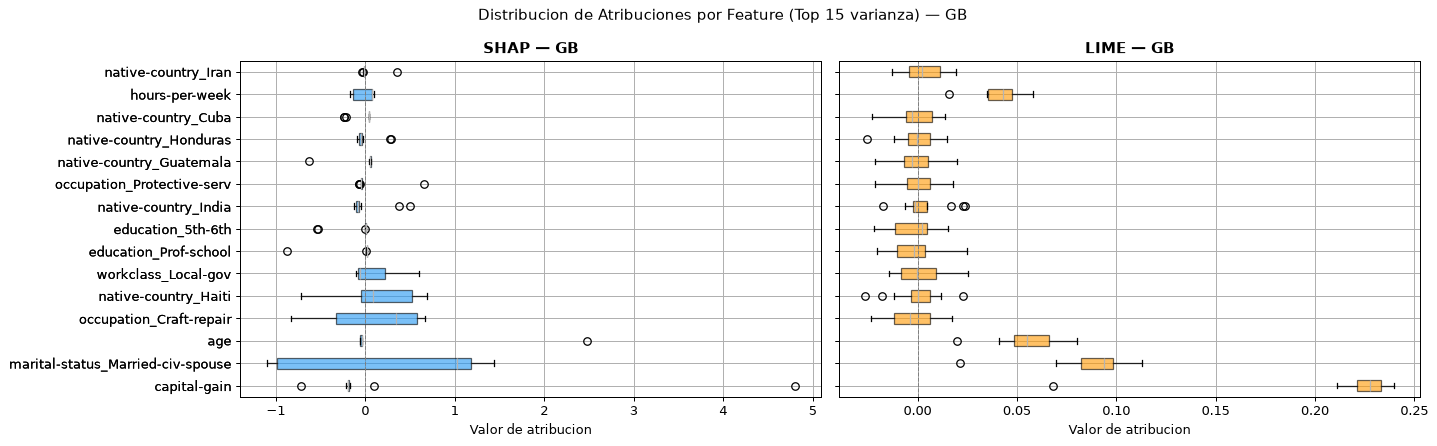

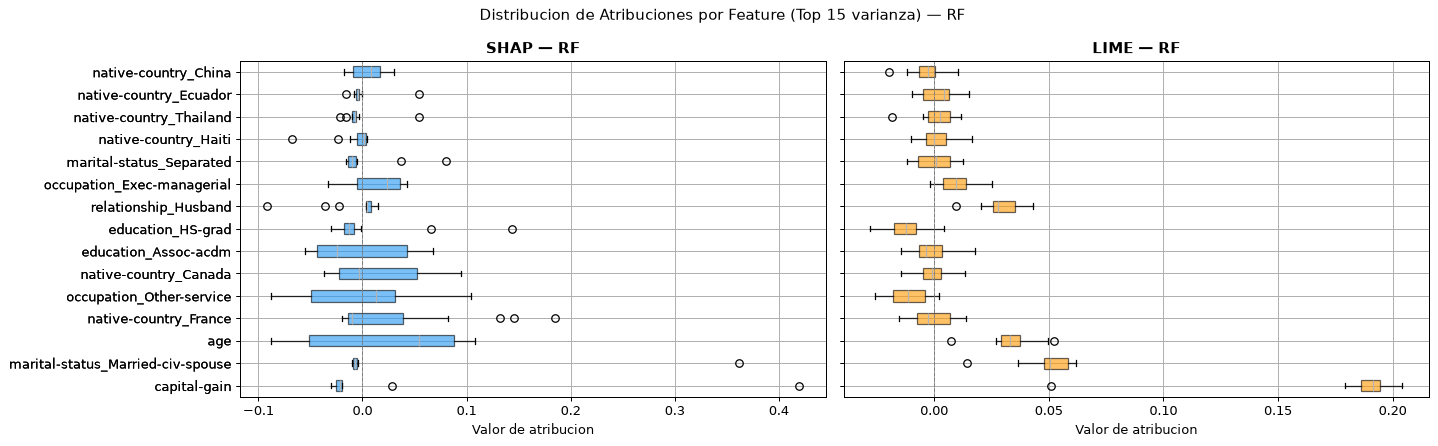

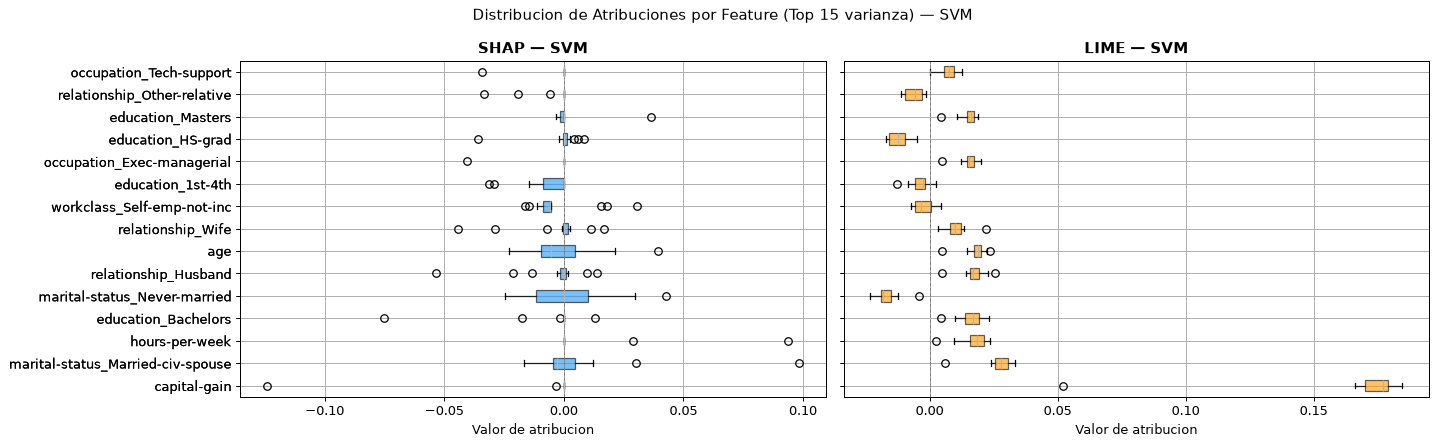

In [19]:
# -- Estabilidad por feature (boxplots SHAP vs LIME) ---------------------------
for name in selected_names:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, (method, attr) in zip(axes,
        [('SHAP', shap_attributions[name]),
         ('LIME', lime_attributions[name])]):

        # Asegurar que attr sea 2D (n_samples, n_features)
        if attr.ndim == 3:
            attr = attr[:, :, 1]   # tomar clase positiva (>50K)

        df_box = pd.DataFrame(attr, columns=feature_names)
        order = df_box.std().sort_values(ascending=False).index[:15]
        df_box[order].boxplot(ax=ax, vert=False,
                               patch_artist=True,
                               boxprops=dict(facecolor=colors[method], alpha=0.6))
        ax.set_title(f'{method} — {name}', fontweight='bold')
        ax.set_xlabel('Valor de atribucion')
        ax.axvline(0, ls='--', lw=0.8, color='gray')

    plt.suptitle(f'Distribucion de Atribuciones por Feature (Top 15 varianza) — {name}',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

### 8.2 Diferencias ∆ entre métodos

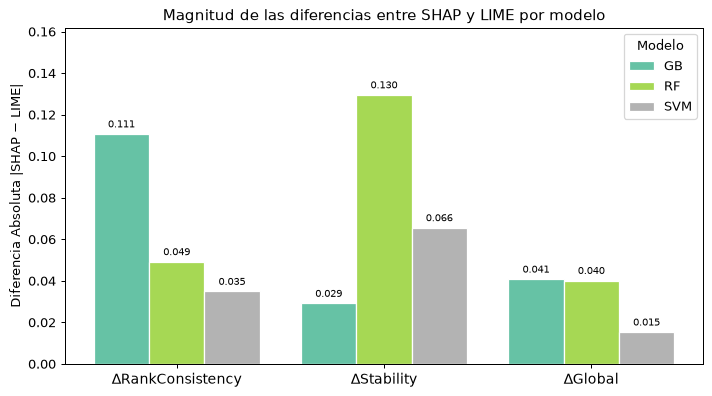

In [20]:
delta_cols = ['HC_\u2206RankConsistency', 'HC_\u2206Stability', 'HC_\u2206Global']
delta_data = comparison_df[delta_cols].copy()

fig, ax = plt.subplots(figsize=(8, max(3, n_models * 1.5)))
x = np.arange(len(delta_cols))
w = 0.8 / n_models
palette = plt.cm.Set2(np.linspace(0, 1, n_models))

for i, (name, row) in enumerate(delta_data.iterrows()):
    offset = (i - n_models / 2 + 0.5) * w
    bars = ax.bar(x + offset, row.values, w,
                  label=name, color=palette[i], edgecolor='white')
    for bar, v in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(['\u2206RankConsistency', '\u2206Stability', '\u2206Global'], fontsize=11)
ax.set_ylabel('Diferencia Absoluta |SHAP \u2212 LIME|')
ax.set_title('Magnitud de las diferencias entre SHAP y LIME por modelo', fontsize=12)
ax.legend(title='Modelo')
ax.set_ylim(0, max(delta_data.values.max() * 1.25, 0.1))
plt.tight_layout()
plt.show()

## 9. Conclusión Final

In [21]:
print("\u2554" + "\u2550" * 62 + "\u2557")
print("\u2551   CONCLUSION: Seleccion del Metodo de Explicabilidad        \u2551")
print("\u2560" + "\u2550" * 62 + "\u2563")
for name, row in comparison_df.iterrows():
    gap = 62 - len(name) - len(row['HC_Winner']) - len(row['HC_Criterion']) - 14
    print(f"\u2551  Modelo {name}:  {row['HC_Winner']} es preferido  [{row['HC_Criterion']}]{' ' * max(0, gap)}\u2551")
print("\u2560" + "\u2550" * 62 + "\u2563")

# Ganador global por GES medio
ges_shap = comparison_df['HC_GES_SHAP'].mean()
ges_lime = comparison_df['HC_GES_LIME'].mean()
global_winner = 'SHAP' if ges_shap >= ges_lime else 'LIME'
print(f"\u2551  GES medio global — SHAP: {ges_shap:.4f} | LIME: {ges_lime:.4f}       \u2551")
print(f"\u2551  \u27a4  Metodo preferido globalmente: {global_winner:4s}                   \u2551")
print("\u255a" + "\u2550" * 62 + "\u255d")

╔══════════════════════════════════════════════════════════════╗
║   CONCLUSION: Seleccion del Metodo de Explicabilidad        ║
╠══════════════════════════════════════════════════════════════╣
║  Modelo GB:  SHAP es preferido  [GES (trade-off)]                           ║
║  Modelo RF:  LIME es preferido  [GES (trade-off)]                           ║
║  Modelo SVM:  LIME es preferido  [GES (trade-off)]                          ║
╠══════════════════════════════════════════════════════════════╣
║  GES medio global — SHAP: 0.7830 | LIME: 0.7879       ║
║  ➤  Metodo preferido globalmente: LIME                   ║
╚══════════════════════════════════════════════════════════════╝


---
## Referencias

- Munoz, C., da Costa, K., Modenesi, B., & Koshiyama, A. (2023). *Evaluating explainability in machine learning predictions through explainer-agnostic metrics*. arXiv:2302.12094.
- Kohavi, R., & Becker, B. (1996). *Adult / Census Income dataset*. UCI Machine Learning Repository. (Uno de los datasets de referencia usados en Muñoz et al. 2023.)
- Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). 'Why should I trust you?': Explaining the predictions of any classifier. *KDD*.

---
## Bloque 1 — Casos de mayor desacuerdo SHAP vs LIME

Para cada instancia del test, calcular la distancia entre los rankings de ambos métodos (tau de Kendall o diferencia de Spearman). Mostrar las top-K instancias donde más discrepan, junto con:

Los valores reales de sus features
Las atribuciones de cada método lado a lado
Si el modelo acertó o erró la predicción

La conjetura explorable: ¿los desacuerdos ocurren más en instancias cercanas a la frontera de decisión (probabilidad ~0.5)? ¿O en personas atípicas (outliers en el espacio de features)?

In [22]:
## Celda 1 -- Setup del analisis cualitativo
# -- Setup Seccion 10 -----------------------------------------------------------
from scipy.stats import kendalltau
from scipy.spatial.distance import cdist

# Usamos el primer modelo seleccionado como caso de estudio principal
# Podes cambiar MODEL_FOCUS a cualquiera de selected_names
MODEL_FOCUS = selected_names[0]

# Asegurar 2D (por si TreeExplainer devolvio 3D)
shap_attr = shap_attributions[MODEL_FOCUS]
lime_attr = lime_attributions[MODEL_FOCUS]
if shap_attr.ndim == 3:
    shap_attr = shap_attr[:, :, 1]
if lime_attr.ndim == 3:
    lime_attr = lime_attr[:, :, 1]

n_test = len(X_test)
model  = fitted_models[MODEL_FOCUS]
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
correct = (y_pred == y_test)

print(f"Modelo de analisis: {MODEL_FOCUS}")
print(f"Instancias test (submuestra XAI): {n_test}  |  Correctas: {correct.sum()}  |  Erroneas: {(~correct).sum()}")

Modelo de analisis: GB
Instancias test (submuestra XAI): 15  |  Correctas: 14  |  Erroneas: 1


Top instancias con mayor desacuerdo SHAP vs LIME
────────────────────────────────────────────────────────────
  #1  inst=  1 | distancia=1.220 | prob_>50K=0.196 | real=<=50K | pred=<=50K | ✓
  #2  inst=  8 | distancia=1.168 | prob_>50K=0.006 | real=<=50K | pred=<=50K | ✓
  #3  inst= 10 | distancia=1.151 | prob_>50K=0.008 | real=<=50K | pred=<=50K | ✓
  #4  inst=  9 | distancia=1.113 | prob_>50K=0.194 | real=>50K | pred=<=50K | ✗
  #5  inst=  5 | distancia=1.112 | prob_>50K=0.734 | real=>50K | pred=>50K | ✓

CONJETURA — Bloque 1
  Correlacion |prob - 0.5| vs desacuerdo: 0.199
  Desacuerdo medio en zona frontera (0.35-0.65): 0.989  (n=1)
  Desacuerdo medio fuera de frontera:            1.091  (n=14)
  Desacuerdo medio en errores:  1.113
  Desacuerdo medio en aciertos: 1.082


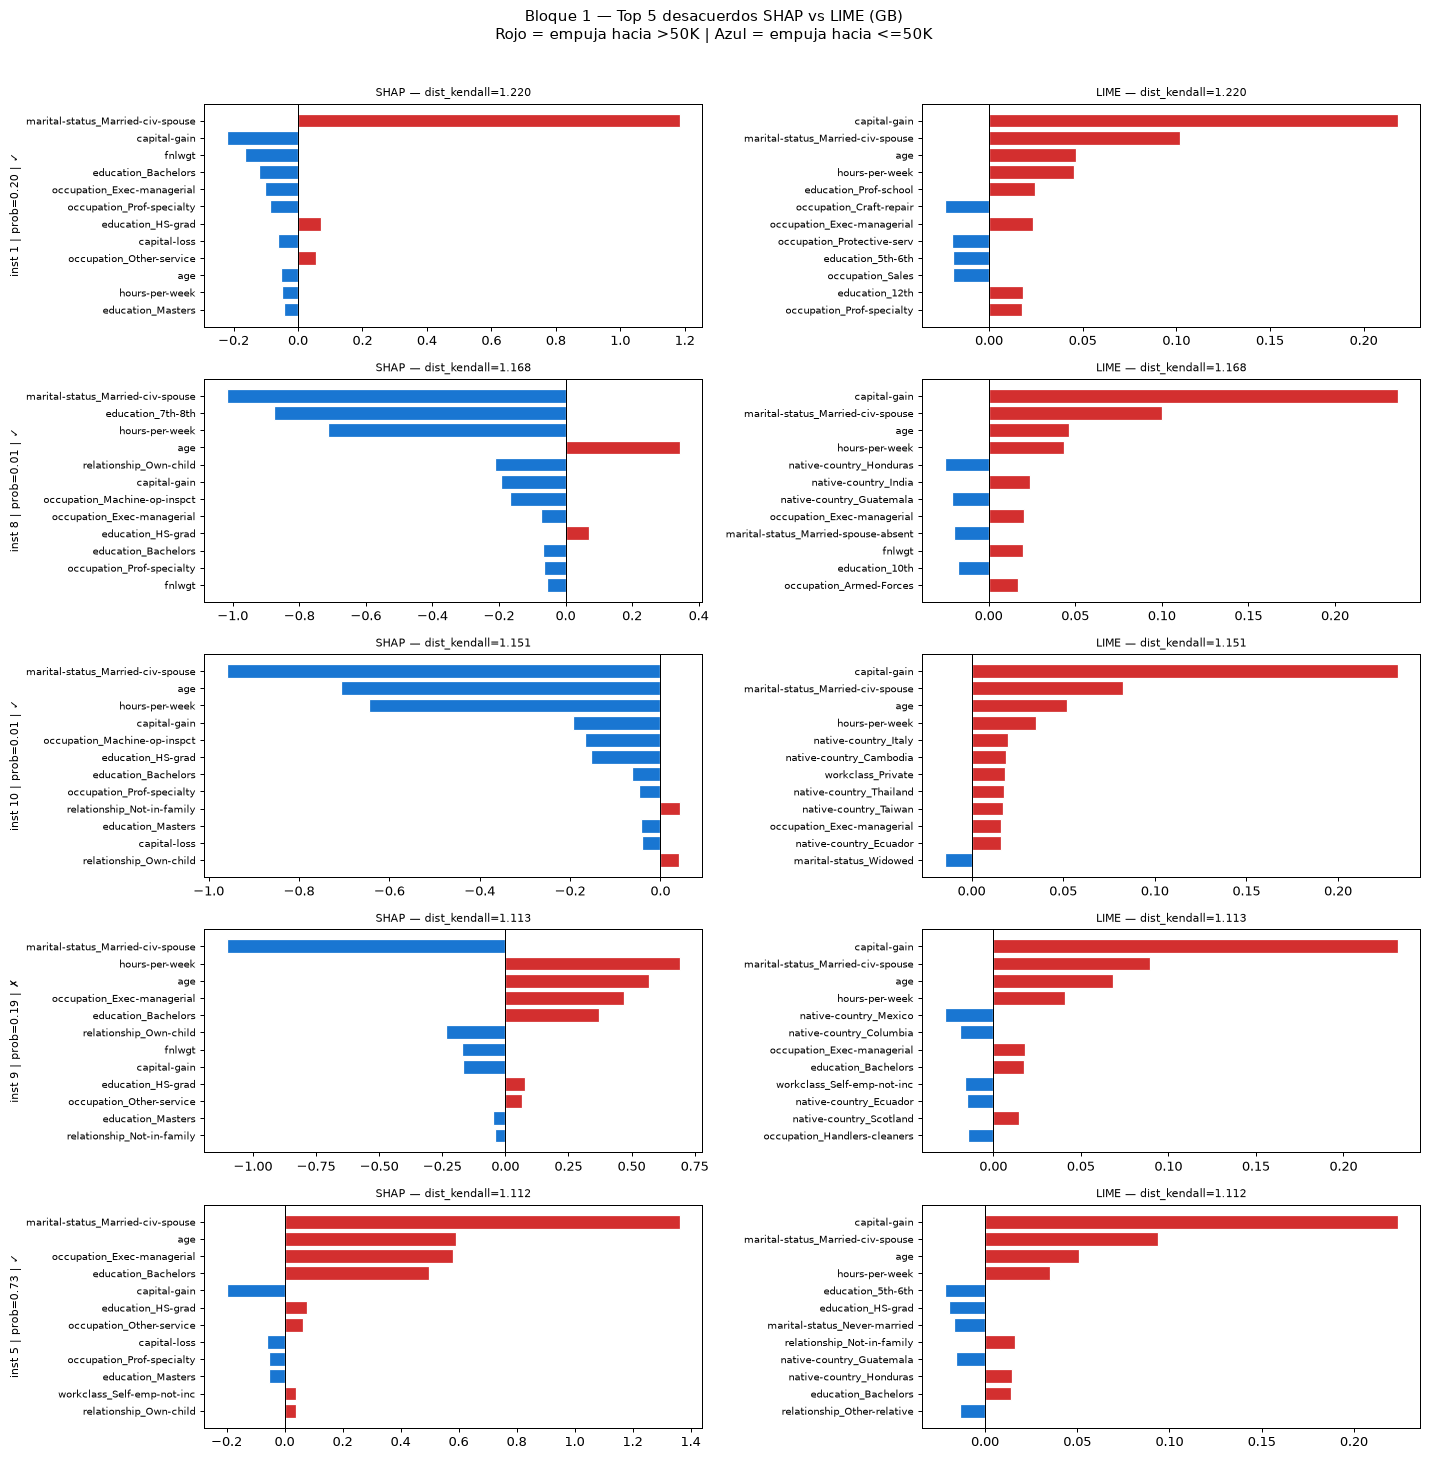

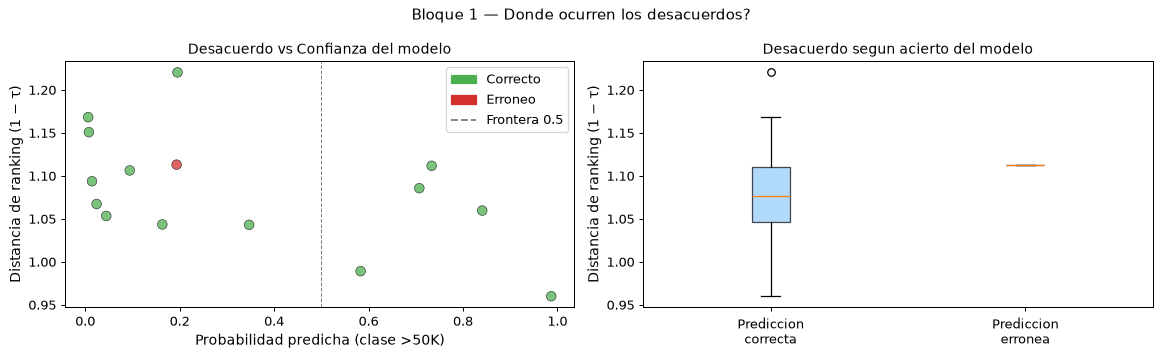

In [23]:
# ==============================================================================
# BLOQUE 1 -- Instancias con mayor desacuerdo entre SHAP y LIME
# ==============================================================================
#Celda 2 -- Bloque 1: Casos de mayor desacuerdo SHAP vs LIME

from scipy.stats import rankdata, kendalltau

# Calcular distancia de ranking (1 - tau de Kendall) para cada instancia
kendall_distances = []
for i in range(n_test):
    tau, _ = kendalltau(shap_attr[i], lime_attr[i])
    kendall_distances.append(1 - tau)   # 0 = acuerdo total, 2 = desacuerdo total

kendall_distances = np.array(kendall_distances)
TOP_K = 5
top_idx = np.argsort(kendall_distances)[::-1][:TOP_K]

print("Top instancias con mayor desacuerdo SHAP vs LIME")
print("\u2500" * 60)
for rank, i in enumerate(top_idx, 1):
    print(f"  #{rank}  inst={i:3d} | distancia={kendall_distances[i]:.3f} | "
          f"prob_>50K={y_prob[i]:.3f} | "
          f"real={LABEL_POS if y_test[i]==1 else LABEL_NEG} | "
          f"pred={LABEL_POS if y_pred[i]==1 else LABEL_NEG} | "
          f"{'\u2713' if correct[i] else '\u2717'}")

# -- Visualizacion: atribuciones lado a lado para cada caso top -------------
fig, axes = plt.subplots(TOP_K, 2, figsize=(16, TOP_K * 3.2))
for row, i in enumerate(top_idx):
    for col, (method, attr) in enumerate([('SHAP', shap_attr), ('LIME', lime_attr)]):
        ax = axes[row, col]
        vals = attr[i]
        idx_sorted = np.argsort(np.abs(vals))[-12:]
        colors_bar = ['#d32f2f' if v > 0 else '#1976d2' for v in vals[idx_sorted]]
        ax.barh([feature_names[k] for k in idx_sorted], vals[idx_sorted],
                color=colors_bar, edgecolor='white')
        ax.axvline(0, color='k', lw=0.8)
        if col == 0:
            status = f"inst {i} | prob={y_prob[i]:.2f} | {'\u2713' if correct[i] else '\u2717'}"
            ax.set_ylabel(status, fontsize=8.5)
        ax.set_title(f"{method} — dist_kendall={kendall_distances[i]:.3f}", fontsize=9)
        ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f'Bloque 1 — Top {TOP_K} desacuerdos SHAP vs LIME ({MODEL_FOCUS})\n'
             f'Rojo = empuja hacia {LABEL_POS} | Azul = empuja hacia {LABEL_NEG}',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# -- Los desacuerdos ocurren cerca de la frontera de decision? ----------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_prob, kendall_distances,
                c=['#d32f2f' if not c else '#4caf50' for c in correct],
                alpha=0.75, edgecolors='k', linewidths=0.5, s=60)
axes[0].axvline(0.5, ls='--', color='gray', lw=0.8, label='frontera (0.5)')
axes[0].set_xlabel(f'Probabilidad predicha (clase {LABEL_POS})', fontsize=11)
axes[0].set_ylabel('Distancia de ranking (1 \u2212 \u03c4)', fontsize=11)
axes[0].set_title('Desacuerdo vs Confianza del modelo', fontsize=11)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#4caf50', label='Correcto'),
                          Patch(color='#d32f2f', label='Erroneo'),
                          plt.Line2D([0],[0], ls='--', color='gray', label='Frontera 0.5')])

# Boxplot: desacuerdo segun correcta/erronea
data_correct = kendall_distances[correct]
data_wrong   = kendall_distances[~correct]
axes[1].boxplot([data_correct, data_wrong],
                tick_labels=['Prediccion\ncorrecta', 'Prediccion\nerronea'],
                patch_artist=True,
                boxprops=dict(facecolor='#90caf9', alpha=0.7))
axes[1].set_ylabel('Distancia de ranking (1 \u2212 \u03c4)', fontsize=11)
axes[1].set_title('Desacuerdo segun acierto del modelo', fontsize=11)

plt.suptitle('Bloque 1 — Donde ocurren los desacuerdos?', fontsize=12)
plt.tight_layout()
plt.show()

# -- Conjetura -------------------------------------------------------------------
frontera_mask = (y_prob > 0.35) & (y_prob < 0.65)
corr_frontera = np.corrcoef(y_prob, kendall_distances)[0, 1]
print("\nCONJETURA — Bloque 1")
print(f"  Correlacion |prob - 0.5| vs desacuerdo: "
      f"{np.corrcoef(np.abs(y_prob - 0.5), kendall_distances)[0,1]:.3f}")
print(f"  Desacuerdo medio en zona frontera (0.35-0.65): "
      f"{kendall_distances[frontera_mask].mean():.3f}  "
      f"(n={frontera_mask.sum()})")
print(f"  Desacuerdo medio fuera de frontera:            "
      f"{kendall_distances[~frontera_mask].mean():.3f}  "
      f"(n={(~frontera_mask).sum()})")
print(f"  Desacuerdo medio en errores:  {data_wrong.mean():.3f}")
print(f"  Desacuerdo medio en aciertos: {data_correct.mean():.3f}")

---
## Bloque 2 — Instabilidad local: ¿dónde falla cada método?
Calcular la contribución de cada instancia a la métrica de Stability (su varianza individual respecto a la media). Identificar las instancias que más "arrastran" la inestabilidad de SHAP vs las de LIME. Cruzar eso con:

Distancia al centroide del training set (¿son instancias lejanas al dominio?)
Predicción del modelo (¿son los errores de clasificación?)

La conjetura explorable: LIME perturba localmente con datos sintéticos, entonces puede ser más inestable en regiones de baja densidad de datos. SHAP usa el background global, entonces puede fallar más en instancias donde la interacción entre features es atípica.

CONJETURA — Bloque 2
  Correlacion (distancia al dominio vs inestabilidad):
    SHAP: 0.337  |  LIME: 0.068
  Correlacion (error de prediccion vs inestabilidad):
    SHAP: -0.052  |  LIME: -0.078

  Instancias lejanas al dominio (Q3=2.59, n=4):
    Inestabilidad SHAP: 1.827  vs cercanas: 1.788
    Inestabilidad LIME: 0.103  vs cercanas: 0.081


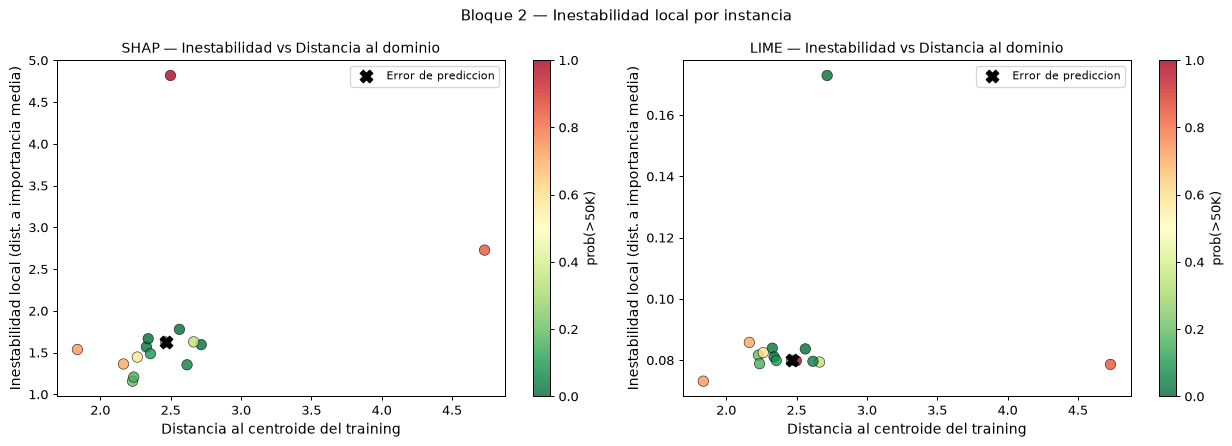

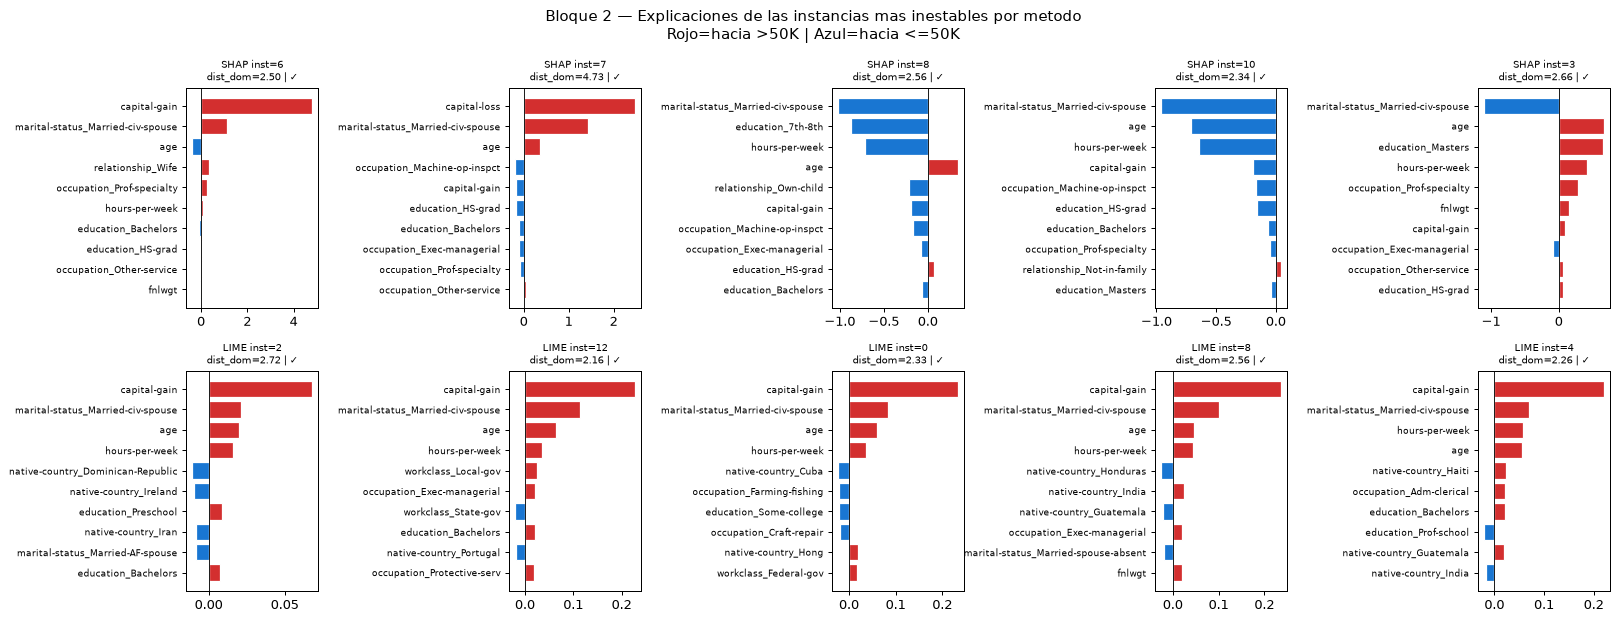

In [24]:
# ==============================================================================
# BLOQUE 2 -- Donde falla cada metodo? Inestabilidad local vs dominio
# ==============================================================================
#Celda 3 -- Bloque 2: Inestabilidad local y distancia al dominio

# Contribucion de cada instancia a la inestabilidad (varianza local)
# Para cada instancia i y metodo, calculamos cuanto se aleja del promedio
def local_instability(attr_matrix):
    """Distancia L2 de cada instancia a la importancia media."""
    mean_attr = attr_matrix.mean(axis=0)
    return np.linalg.norm(attr_matrix - mean_attr, axis=1)

instab_shap = local_instability(shap_attr)
instab_lime = local_instability(lime_attr)

# Distancia de cada instancia de test al centroide del entrenamiento
centroid_train = X_train.mean(axis=0)
dist_to_domain = np.linalg.norm(X_test - centroid_train, axis=1)

# -- Visualizacion principal ------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, instab) in zip(axes, [('SHAP', instab_shap), ('LIME', instab_lime)]):
    sc = ax.scatter(dist_to_domain, instab,
                    c=y_prob, cmap='RdYlGn_r',
                    alpha=0.8, edgecolors='k', linewidths=0.5, s=70,
                    vmin=0, vmax=1)
    # Marcar errores con X
    ax.scatter(dist_to_domain[~correct], instab[~correct],
               marker='X', color='black', s=100, zorder=5, label='Error de prediccion')
    plt.colorbar(sc, ax=ax, label=f'prob({LABEL_POS})')
    ax.set_xlabel('Distancia al centroide del training', fontsize=11)
    ax.set_ylabel('Inestabilidad local (dist. a importancia media)', fontsize=11)
    ax.set_title(f'{method} — Inestabilidad vs Distancia al dominio', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Bloque 2 — Inestabilidad local por instancia', fontsize=12)
plt.tight_layout()
plt.show()

# -- Instancias mas inestables de cada metodo ----------------------------------
TOP_INSTAB = 5
fig, axes = plt.subplots(2, TOP_INSTAB, figsize=(18, 7))
for row, (method, instab, attr) in enumerate([
        ('SHAP', instab_shap, shap_attr),
        ('LIME', instab_lime, lime_attr)]):
    top_inst = np.argsort(instab)[::-1][:TOP_INSTAB]
    for col, i in enumerate(top_inst):
        ax = axes[row, col]
        vals = attr[i]
        idx_s = np.argsort(np.abs(vals))[-10:]
        bar_colors = ['#d32f2f' if v > 0 else '#1976d2' for v in vals[idx_s]]
        ax.barh([feature_names[k] for k in idx_s], vals[idx_s],
                color=bar_colors, edgecolor='white')
        ax.axvline(0, color='k', lw=0.7)
        ax.set_title(
            f"{method} inst={i}\n"
            f"dist_dom={dist_to_domain[i]:.2f} | "
            f"{'\u2713' if correct[i] else '\u2717'}",
            fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

plt.suptitle(f'Bloque 2 — Explicaciones de las instancias mas inestables por metodo\n'
             f'Rojo=hacia {LABEL_POS} | Azul=hacia {LABEL_NEG}', fontsize=12)
plt.tight_layout()
plt.show()

# -- Correlaciones y conjetura --------------------------------------------------
corr_shap = np.corrcoef(dist_to_domain, instab_shap)[0, 1]
corr_lime = np.corrcoef(dist_to_domain, instab_lime)[0, 1]
corr_shap_err = np.corrcoef((~correct).astype(int), instab_shap)[0, 1]
corr_lime_err = np.corrcoef((~correct).astype(int), instab_lime)[0, 1]

print("CONJETURA — Bloque 2")
print(f"  Correlacion (distancia al dominio vs inestabilidad):")
print(f"    SHAP: {corr_shap:.3f}  |  LIME: {corr_lime:.3f}")
print(f"  Correlacion (error de prediccion vs inestabilidad):")
print(f"    SHAP: {corr_shap_err:.3f}  |  LIME: {corr_lime_err:.3f}")
print()
q3 = np.percentile(dist_to_domain, 75)
far_mask = dist_to_domain > q3
print(f"  Instancias lejanas al dominio (Q3={q3:.2f}, n={far_mask.sum()}):")
print(f"    Inestabilidad SHAP: {instab_shap[far_mask].mean():.3f}  "
      f"vs cercanas: {instab_shap[~far_mask].mean():.3f}")
print(f"    Inestabilidad LIME: {instab_lime[far_mask].mean():.3f}  "
      f"vs cercanas: {instab_lime[~far_mask].mean():.3f}")

## Bloque 3 — Análisis de features "conflictivas"
Para cada feature, calcular cuántas veces SHAP y LIME difieren en el signo de la atribución (una dice que empuja hacia ingreso alto, la otra hacia ingreso bajo). Mostrar un heatmap instancias × features con los conflictos de signo. Elegir 2-3 features con más conflictos y graficar su distribución de valores en train vs las instancias conflictivas.
La conjetura explorable: los conflictos de signo podrían concentrarse en features con distribución bimodal o con interacciones no lineales fuertes con otras features, donde la linealización local de LIME y la marginalización de SHAP llevan a interpretaciones opuestas.

CONJETURA — Bloque 3

  Feature: education_Bachelors  (conflicto en 13/15 instancias)
    Valor medio train:        0.1681  ±0.3740
    Valor medio conflictivas: 0.0000  ±0.0000
    Desplazamiento (z-score): 0.450
    prob media conflictivas:  0.309  (zona frontera: 1 inst.)

  Feature: capital-gain  (conflicto en 13/15 instancias)
    Valor medio train:        -0.0000  ±1.0000
    Valor medio conflictivas: -0.0961  ±0.1775
    Desplazamiento (z-score): 0.096
    prob media conflictivas:  0.278  (zona frontera: 1 inst.)

  Feature: relationship_Wife  (conflicto en 12/15 instancias)
    Valor medio train:        0.0461  ±0.2097
    Valor medio conflictivas: 0.0000  ±0.0000
    Desplazamiento (z-score): 0.220
    prob media conflictivas:  0.300  (zona frontera: 1 inst.)


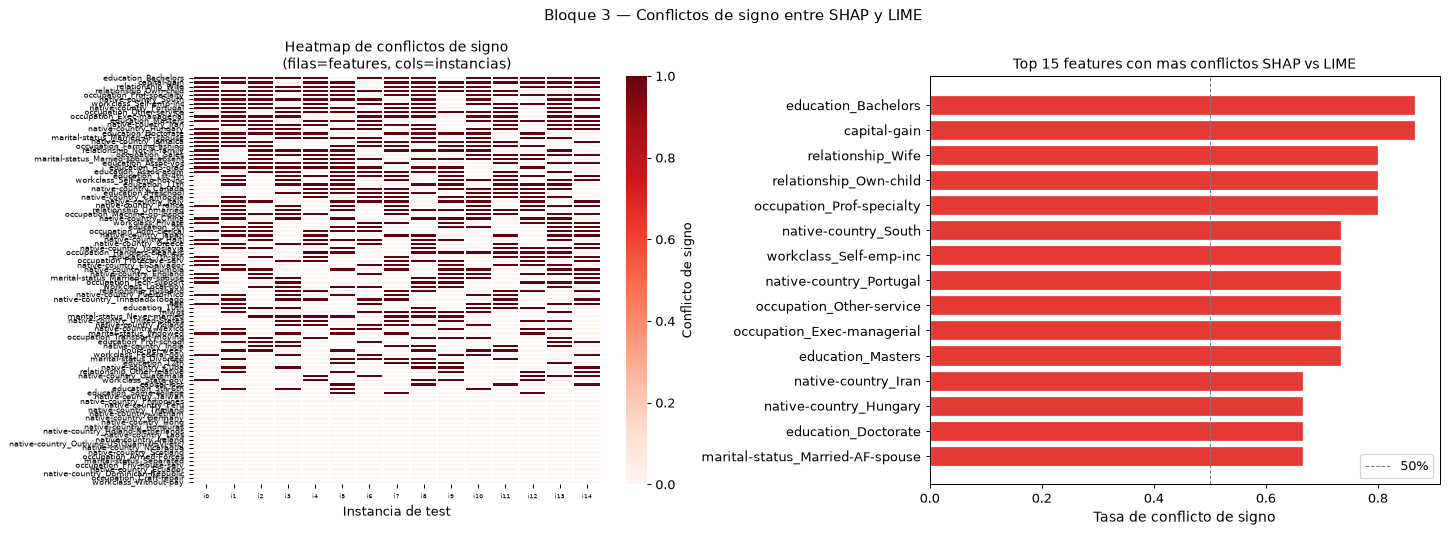

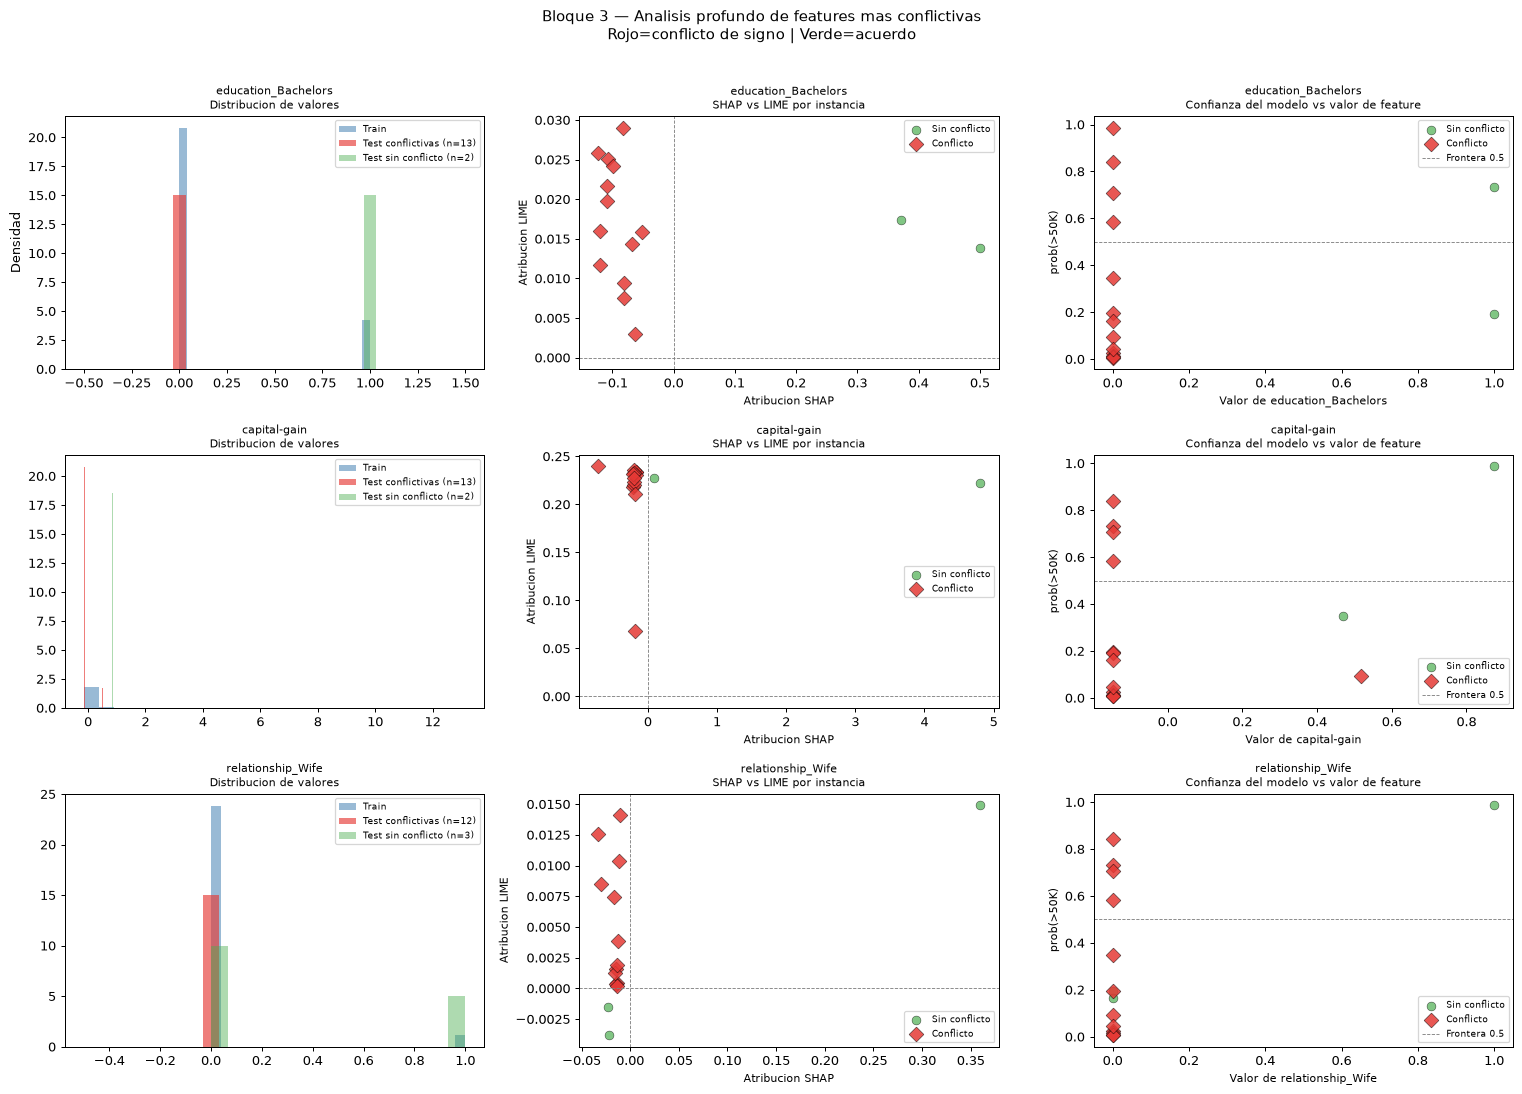

In [25]:
# ==============================================================================
# BLOQUE 3 -- Features con conflictos de signo entre SHAP y LIME
# ==============================================================================
#Celda 4 -- Bloque 3: Features con conflictos de signo

# Conflicto de signo: SHAP y LIME tienen signo opuesto (excluyendo ceros)
sign_shap = np.sign(shap_attr)
sign_lime = np.sign(lime_attr)

# Conflicto = signos opuestos y ninguno es cero
conflict_matrix = (sign_shap * sign_lime) < 0   # shape (n_test, n_features)
conflict_rate   = conflict_matrix.mean(axis=0)   # por feature

# -- Heatmap instancias x features ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ordenar features por tasa de conflicto
feat_order = np.argsort(conflict_rate)[::-1]
feat_labels = [feature_names[i] for i in feat_order]

sns.heatmap(conflict_matrix[:, feat_order].T.astype(int),
            ax=axes[0],
            cmap='Reds', cbar_kws={'label': 'Conflicto de signo'},
            xticklabels=[f"i{i}" for i in range(n_test)],
            yticklabels=feat_labels,
            linewidths=0.2)
axes[0].set_title('Heatmap de conflictos de signo\n(filas=features, cols=instancias)',
                  fontsize=11)
axes[0].set_xlabel('Instancia de test')
axes[0].tick_params(axis='y', labelsize=6)
axes[0].tick_params(axis='x', labelsize=5)

# Barplot: tasa de conflicto por feature (top 15)
top15_feat = feat_order[:15]
axes[1].barh([feature_names[i] for i in top15_feat[::-1]],
             conflict_rate[top15_feat[::-1]],
             color='#e53935', edgecolor='white')
axes[1].set_xlabel('Tasa de conflicto de signo', fontsize=11)
axes[1].set_title('Top 15 features con mas conflictos SHAP vs LIME', fontsize=11)
axes[1].axvline(0.5, ls='--', color='gray', lw=0.8, label='50%')
axes[1].legend()

plt.suptitle('Bloque 3 — Conflictos de signo entre SHAP y LIME', fontsize=12)
plt.tight_layout()
plt.show()

# -- Analisis profundo: top 3 features conflictivas ----------------------------
TOP_FEAT = 3
top_conflict_features = feat_order[:TOP_FEAT]

fig, axes = plt.subplots(TOP_FEAT, 3, figsize=(17, TOP_FEAT * 4))

for row, fi in enumerate(top_conflict_features):
    fname = feature_names[fi]
    conflict_mask = conflict_matrix[:, fi]

    # Col 0: distribucion del valor de la feature en train vs instancias conflictivas
    ax = axes[row, 0]
    ax.hist(X_train[:, fi], bins=25, alpha=0.55, color='steelblue',
            density=True, label='Train')
    ax.hist(X_test[conflict_mask, fi], bins=15, alpha=0.65, color='#e53935',
            density=True, label=f'Test conflictivas (n={conflict_mask.sum()})')
    ax.hist(X_test[~conflict_mask, fi], bins=15, alpha=0.45, color='#4caf50',
            density=True, label=f'Test sin conflicto (n={(~conflict_mask).sum()})')
    ax.set_title(f'{fname}\nDistribucion de valores', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel(f'Densidad' if row == 0 else '')

    # Col 1: atribuciones SHAP y LIME para esta feature, coloreadas por conflicto
    ax = axes[row, 1]
    ax.scatter(shap_attr[~conflict_mask, fi], lime_attr[~conflict_mask, fi],
               color='#4caf50', alpha=0.7, s=50, label='Sin conflicto', edgecolors='k', lw=0.4)
    ax.scatter(shap_attr[conflict_mask, fi], lime_attr[conflict_mask, fi],
               color='#e53935', alpha=0.85, s=70, label='Conflicto', edgecolors='k', lw=0.4,
               marker='D')
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_xlabel('Atribucion SHAP', fontsize=9)
    ax.set_ylabel('Atribucion LIME', fontsize=9)
    ax.set_title(f'{fname}\nSHAP vs LIME por instancia', fontsize=9)
    ax.legend(fontsize=7)

    # Col 2: los conflictos se relacionan con la confianza del modelo?
    ax = axes[row, 2]
    ax.scatter(X_test[~conflict_mask, fi], y_prob[~conflict_mask],
               color='#4caf50', alpha=0.7, s=50, label='Sin conflicto', edgecolors='k', lw=0.4)
    ax.scatter(X_test[conflict_mask, fi], y_prob[conflict_mask],
               color='#e53935', alpha=0.85, s=70, label='Conflicto', edgecolors='k', lw=0.4,
               marker='D')
    ax.axhline(0.5, color='gray', lw=0.7, ls='--', label='Frontera 0.5')
    ax.set_xlabel(f'Valor de {fname}', fontsize=9)
    ax.set_ylabel(f'prob({LABEL_POS})', fontsize=9)
    ax.set_title(f'{fname}\nConfianza del modelo vs valor de feature', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Bloque 3 — Analisis profundo de features mas conflictivas\n'
             'Rojo=conflicto de signo | Verde=acuerdo', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# -- Conjetura -------------------------------------------------------------------
print("CONJETURA — Bloque 3")
for fi in top_conflict_features:
    fname = feature_names[fi]
    conflict_mask = conflict_matrix[:, fi]
    vals_conflict  = X_test[conflict_mask, fi]
    vals_no_conflict = X_test[~conflict_mask, fi]
    vals_train = X_train[:, fi]

    # Bimodalidad aproximada: diferencia entre media de train y de conflictivas
    shift = abs(vals_conflict.mean() - vals_train.mean()) / (vals_train.std() + 1e-9)
    print(f"\n  Feature: {fname}  (conflicto en {conflict_mask.sum()}/{n_test} instancias)")
    print(f"    Valor medio train:        {vals_train.mean():.4f}  \u00b1{vals_train.std():.4f}")
    print(f"    Valor medio conflictivas: {vals_conflict.mean():.4f}  \u00b1{vals_conflict.std():.4f}")
    print(f"    Desplazamiento (z-score): {shift:.3f}")
    print(f"    prob media conflictivas:  {y_prob[conflict_mask].mean():.3f}  "
          f"(zona frontera: {((y_prob[conflict_mask] > 0.35) & (y_prob[conflict_mask] < 0.65)).sum()} inst.)")

---
## Gráfico de Ranking de Features

La tabla de abajo tiene las 96 features (one-hot/escaladas) con su importancia media absoluta según
SHAP y LIME, su posición en el ranking de cada método, y `rank_diff` (cuántas
posiciones sube o baja una feature entre los dos métodos) — las diferencias
grandes son los mismos conflictos que salieron en el Bloque 3.

El bump chart del panel derecho me sirve para ver eso mismo de forma visual:
cada línea es una feature, y las rojas son las que más cambian de posición
entre SHAP y LIME.


  Modelo: GB — Ranking completo de features
                                  Feature  SHAP_mean_abs  LIME_mean_abs  SHAP_rank  LIME_rank  rank_diff
        marital-status_Married-civ-spouse       1.113037       0.086521          1          2         -1
                             capital-gain       0.527925       0.217099          2          1          1
                                      age       0.491139       0.055655          3          3          0
                           hours-per-week       0.357446       0.042093          4          4          0
                             capital-loss       0.209267       0.004711          5         90        -85
               occupation_Exec-managerial       0.201391       0.014242          6          6          0
                      education_Bachelors       0.138948       0.016987          7          5          2
                        education_HS-grad       0.100113       0.010778          8          8          0
          

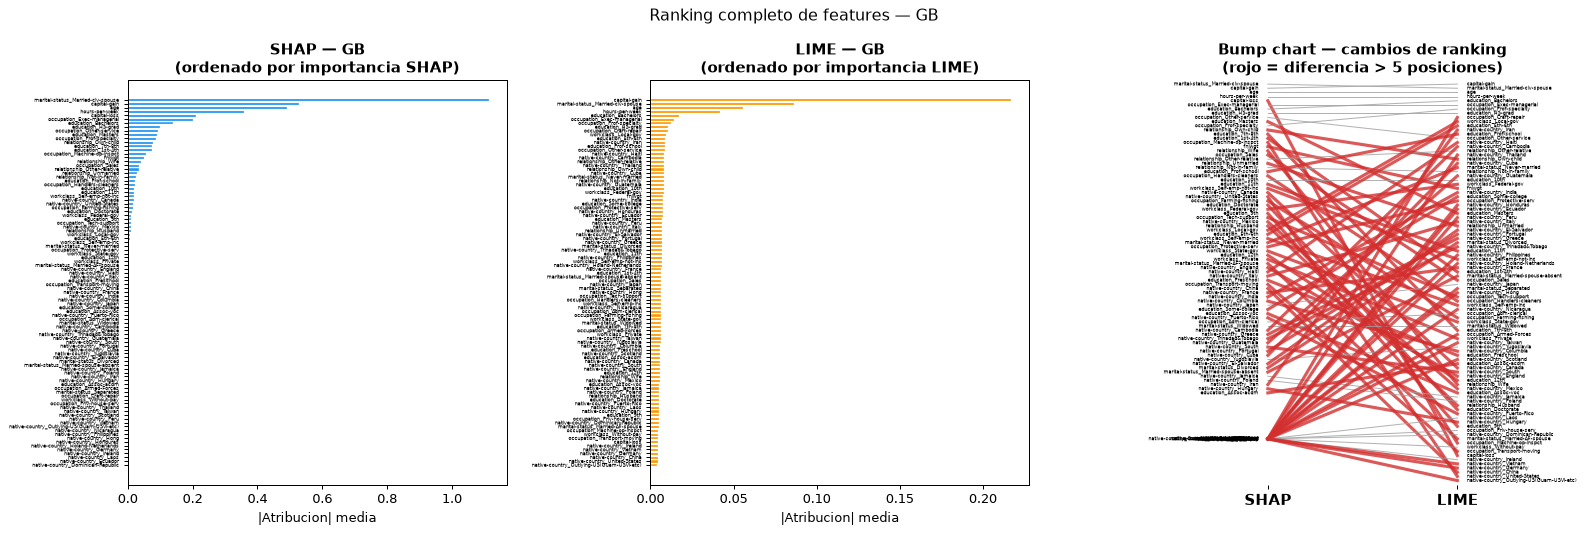

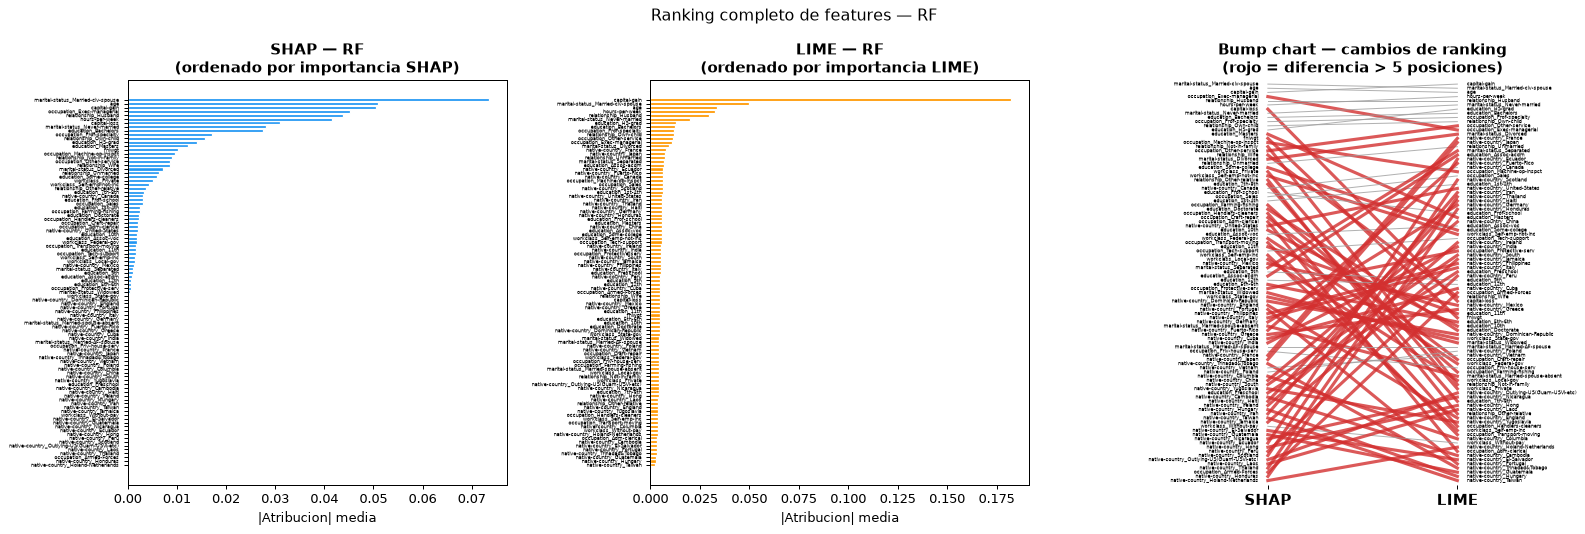

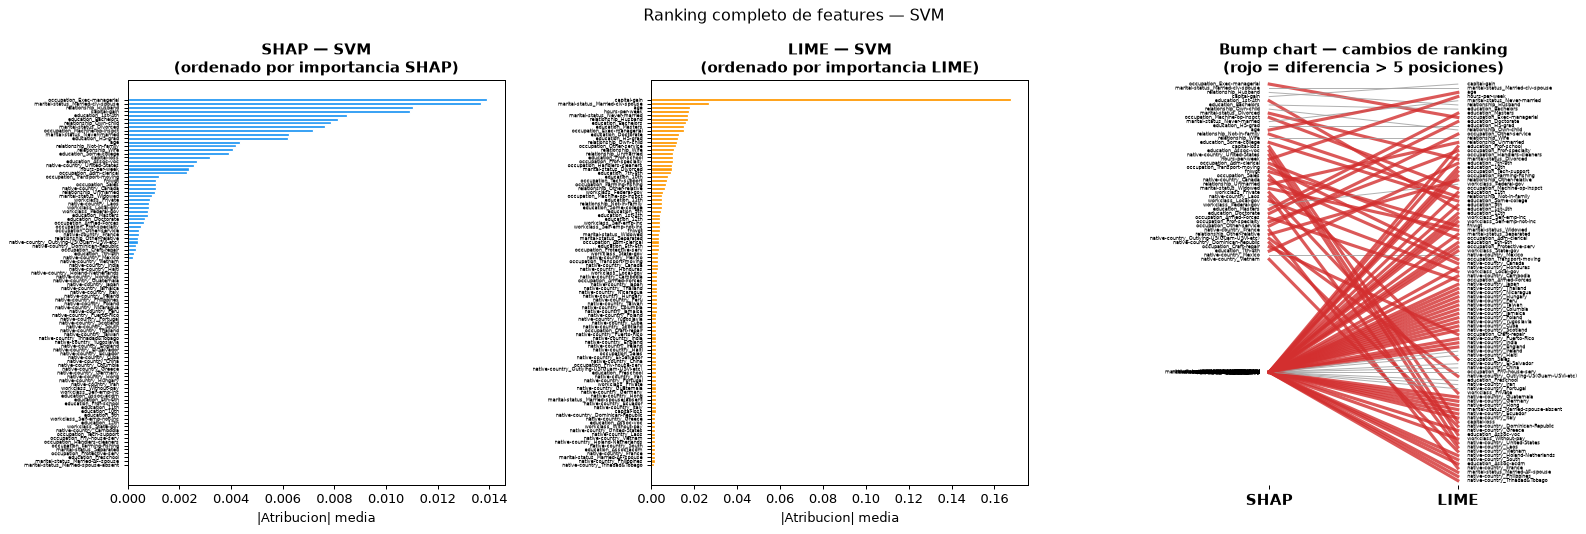

In [26]:
# -- Ranking completo de features por metodo -----------------------------------
import pandas as pd
import matplotlib.pyplot as plt

for name in selected_names:
    shap_a = shap_attributions[name]
    lime_a = lime_attributions[name]
    if shap_a.ndim == 3:
        shap_a = shap_a[:, :, 1]

    # Importancia media absoluta por feature
    shap_importance = np.abs(shap_a).mean(axis=0)
    lime_importance = np.abs(lime_a).mean(axis=0)

    ranking = pd.DataFrame({
        'Feature':         feature_names,
        'SHAP_mean_abs':   shap_importance,
        'LIME_mean_abs':   lime_importance,
        'SHAP_rank':       pd.Series(shap_importance).rank(ascending=False).astype(int).values,
        'LIME_rank':       pd.Series(lime_importance).rank(ascending=False).astype(int).values,
    }).sort_values('SHAP_rank')

    ranking['rank_diff'] = ranking['SHAP_rank'] - ranking['LIME_rank']

    print(f"\n{'='*65}")
    print(f"  Modelo: {name} — Ranking completo de features")
    print(f"{'='*65}")
    print(ranking.to_string(index=False))

    # -- Visualizacion comparativa de rankings ---------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Barplot SHAP
    shap_sorted = ranking.sort_values('SHAP_mean_abs', ascending=True)
    axes[0].barh(shap_sorted['Feature'], shap_sorted['SHAP_mean_abs'],
                 color='#2196F3', edgecolor='white')
    axes[0].set_title(f'SHAP — {name}\n(ordenado por importancia SHAP)', fontweight='bold')
    axes[0].set_xlabel('|Atribucion| media')
    axes[0].tick_params(axis='y', labelsize=4)

    # Barplot LIME
    lime_sorted = ranking.sort_values('LIME_mean_abs', ascending=True)
    axes[1].barh(lime_sorted['Feature'], lime_sorted['LIME_mean_abs'],
                 color='#FF9800', edgecolor='white')
    axes[1].set_title(f'LIME — {name}\n(ordenado por importancia LIME)', fontweight='bold')
    axes[1].set_xlabel('|Atribucion| media')
    axes[1].tick_params(axis='y', labelsize=4)

    # Bump chart: evolucion del ranking entre metodos
    ax = axes[2]
    for _, row in ranking.iterrows():
        color = '#d32f2f' if abs(row['rank_diff']) > 5 else '#9e9e9e'
        lw    = 2.5 if abs(row['rank_diff']) > 5 else 0.8
        ax.plot([0, 1],
                [row['SHAP_rank'], row['LIME_rank']],
                color=color, lw=lw, alpha=0.8)
        ax.text(-0.05, row['SHAP_rank'], row['Feature'],
                ha='right', va='center', fontsize=4)
        ax.text(1.05, row['LIME_rank'], row['Feature'],
                ha='left', va='center', fontsize=4)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(len(feature_names) + 1, 0)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['SHAP', 'LIME'], fontsize=12, fontweight='bold')
    ax.set_ylabel('Ranking (1 = mas importante)')
    ax.set_title(f'Bump chart — cambios de ranking\n(rojo = diferencia > 5 posiciones)',
                 fontweight='bold')
    ax.yaxis.set_visible(False)
    ax.spines[['left','right','top','bottom']].set_visible(False)

    plt.suptitle(f'Ranking completo de features — {name}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [27]:
# -- Exportar valores de las feature attributions (96 features) ---------------
import os
import pandas as pd
import numpy as np

os.makedirs('results', exist_ok=True)

# Crear DataFrame base con los nombres de las features
attr_df = pd.DataFrame({'Feature': feature_names})

for name in selected_names:
    # 1. Procesar SHAP
    shap_vals = shap_attributions[name]
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]  # clase positiva
    attr_df[f'{name}_SHAP'] = np.abs(shap_vals).mean(axis=0)

    # 2. Procesar LIME
    lime_vals = lime_attributions[name]
    attr_df[f'{name}_LIME'] = np.abs(lime_vals).mean(axis=0)

# Exportar a CSV (distinto nombre para no pisar el del notebook QSAR)
export_path = os.path.join('results', 'feature_attributions_adult.csv')
attr_df.to_csv(export_path, index=False, sep=';')
print(f'Valores de Atribucion (Media Absoluta) exportados a: {export_path}')
print(attr_df.head(len(feature_names)))

Valores de Atribucion (Media Absoluta) exportados a: results\feature_attributions_adult.csv
                           Feature   GB_SHAP  ...  SVM_SHAP  SVM_LIME
0                              age  0.491139  ...  0.004363  0.018123
1                           fnlwgt  0.050719  ...  0.001109  0.003808
2                     capital-gain  0.527925  ...  0.010918  0.167496
3                     capital-loss  0.209267  ...  0.003183  0.001943
4                   hours-per-week  0.357446  ...  0.002373  0.017528
..                             ...       ...  ...       ...       ...
91         native-country_Thailand  0.000000  ...  0.000000  0.002616
92  native-country_Trinadad&Tobago  0.000045  ...  0.000000  0.001328
93    native-country_United-States  0.015831  ...  0.002576  0.001867
94          native-country_Vietnam  0.000000  ...  0.000010  0.001799
95       native-country_Yugoslavia  0.000029  ...  0.000000  0.002328

[96 rows x 7 columns]


In [28]:
# -- Porcentaje de coincidencia Top 15 (SHAP vs LIME) por modelo --
top_k = 15
print(f"\n--- Coincidencia Top {top_k} features (SHAP vs LIME) ---")
overlap_results = {}

for name in selected_names:
    if f'{name}_SHAP' in attr_df.columns and f'{name}_LIME' in attr_df.columns:
        # Obtener los top K features para SHAP y LIME
        top_shap = set(attr_df.nlargest(top_k, f'{name}_SHAP')['Feature'])
        top_lime = set(attr_df.nlargest(top_k, f'{name}_LIME')['Feature'])

        # Calcular interseccion
        intersection = top_shap.intersection(top_lime)
        overlap_pct = (len(intersection) / top_k) * 100
        overlap_results[name] = overlap_pct

        print(f'Modelo {name}: {overlap_pct:.2f}% de coincidencia ({len(intersection)}/{top_k} features)')
        print(f'   Features en comun: {", ".join(intersection)}\n')


--- Coincidencia Top 15 features (SHAP vs LIME) ---
Modelo GB: 60.00% de coincidencia (9/15 features)
   Features en comun: occupation_Exec-managerial, education_Bachelors, occupation_Other-service, age, capital-gain, hours-per-week, marital-status_Married-civ-spouse, education_HS-grad, occupation_Prof-specialty

Modelo RF: 73.33% de coincidencia (11/15 features)
   Features en comun: occupation_Exec-managerial, relationship_Own-child, relationship_Husband, education_Bachelors, age, capital-gain, hours-per-week, marital-status_Married-civ-spouse, marital-status_Never-married, education_HS-grad, occupation_Prof-specialty

Modelo SVM: 66.67% de coincidencia (10/15 features)
   Features en comun: occupation_Exec-managerial, relationship_Own-child, relationship_Husband, education_Bachelors, age, relationship_Wife, marital-status_Never-married, marital-status_Married-civ-spouse, education_HS-grad, capital-gain

